# Dynamic-DeepHit: RNN + Attention (Competing Risks)

This notebook implements a dynamic version of the static DeepHit RNN-attention baseline.

Key idea:
- Use dynamic sequences `lob_sequence` and `toxicity_sequence` as model inputs
- Keep competing-risk setup for events: 0=censored, 1=favorable fill, 2=toxic fill
- Add Dynamic-DeepHit style auxiliary next-step sequence prediction loss

Important data note verified in this notebook:
- First 20 steps of `lob_sequence` match `entry_representation`
- First 20 steps of `toxicity_sequence` match `toxicity_representation`

## 1. Imports and Runtime Setup

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from pycox.models import DeepHit
from pycox.models.data import pair_rank_mat
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.evaluation import EvalSurv

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline

SEED = 4718
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)

if device.type == 'cpu':
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print('CPU threads configured:', cpu_threads)

PyTorch: 2.10.0+cpu
Device: cpu
CPU threads configured: 8


## 2. Load Dataset

In [2]:
DATASET_PATH = PROJECT_ROOT / 'data' / 'datasets' / 'dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet'

query = f"SELECT * FROM '{DATASET_PATH}'"
df_raw = duckdb.query(query).df()

required_cols = [
    'duration_s', 'event_type', 'entry_time', 'side',
    'entry_representation', 'toxicity_representation',
    'lob_sequence', 'toxicity_sequence'
]
missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print('Dataset path:', DATASET_PATH)
print('Shape:', df_raw.shape)
print('Columns:', len(df_raw.columns))

Dataset path: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\data\datasets\dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet
Shape: (64000, 23)
Columns: 23


## 3. Verify First-20 Sequence Consistency

This sanity-check verifies that:
- `lob_sequence[:20]` matches `entry_representation`
- `toxicity_sequence[:20]` matches `toxicity_representation`

In [3]:
LOB_DIM = 41
TOX_DIM = 19

def safe_stack(rep, feat_dim):
    if rep is None:
        return np.empty((0, feat_dim), dtype=np.float32)
    rows = [np.asarray(r, dtype=np.float32).reshape(-1) for r in rep]
    if len(rows) == 0:
        return np.empty((0, feat_dim), dtype=np.float32)
    arr = np.stack(rows, axis=0)
    if arr.ndim != 2 or arr.shape[1] != feat_dim:
        raise ValueError(f'Unexpected shape {arr.shape}; expected (*, {feat_dim})')
    return arr

rng = np.random.default_rng(SEED)
sample_n = min(256, len(df_raw))
sample_idx = rng.choice(len(df_raw), size=sample_n, replace=False)

lob_mismatch = 0
tox_mismatch = 0
checked = 0

for i in sample_idx:
    row = df_raw.iloc[int(i)]
    entry = safe_stack(row['entry_representation'], LOB_DIM)
    tox_entry = safe_stack(row['toxicity_representation'], TOX_DIM)
    lob_seq = safe_stack(row['lob_sequence'], LOB_DIM)
    tox_seq = safe_stack(row['toxicity_sequence'], TOX_DIM)

    if entry.shape[0] == 0 or tox_entry.shape[0] == 0:
        continue

    m_lob = min(20, entry.shape[0], lob_seq.shape[0])
    m_tox = min(20, tox_entry.shape[0], tox_seq.shape[0])

    if m_lob > 0 and not np.allclose(entry[:m_lob], lob_seq[:m_lob], atol=1e-5):
        lob_mismatch += 1
    if m_tox > 0 and not np.allclose(tox_entry[:m_tox], tox_seq[:m_tox], atol=1e-5):
        tox_mismatch += 1

    checked += 1

print('Rows checked:', checked)
print('LOB first-20 mismatches:', lob_mismatch)
print('Toxicity first-20 mismatches:', tox_mismatch)

Rows checked: 256
LOB first-20 mismatches: 0
Toxicity first-20 mismatches: 0


## 4. Build Dynamic Sequence Features

Input per timestep is concatenated as:
- LOB sequence features (41)
- Toxicity sequence features (19, including queue position)
- Side channel (1)
- Validity mask (1)

Total feature dimension: 62

Padding convention:
- Right-padding with zeros
- Mask feature equals 1 on valid timesteps, 0 on padded timesteps

Raw sequence length distribution:
  count : 64,000
  min   : 20
  p25   : 22
  p50   : 28
  p75   : 47
  p90   : 109
  p95   : 217
  p99   : 1013
  max   : 106871

Length bins (left-inclusive, right-exclusive):
  [  0,  20):        0
  [ 20,  40):   44,398
  [ 40,  60):    7,279
  [ 60,  80):    3,274
  [ 80, 100):    1,972
  [100, 128):    1,615
  [128, 160):    1,069
  [160, 256):    1,708
  [256, 106872):    2,685


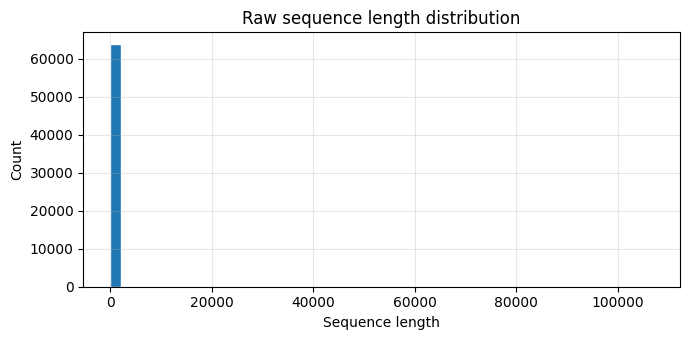

In [4]:
# Sequence-length distribution
raw_lob_len = df_raw['lob_sequence'].map(lambda x: len(x) if x is not None else 0).astype(int)
raw_tox_len = df_raw['toxicity_sequence'].map(lambda x: len(x) if x is not None else 0).astype(int)

raw_len = np.minimum(raw_lob_len.to_numpy(), raw_tox_len.to_numpy())

if 'sequence_length' in df_raw.columns:
    seq_len_col = pd.to_numeric(df_raw['sequence_length'], errors='coerce').to_numpy()
    use_col = np.isfinite(seq_len_col) & (seq_len_col > 0)
    raw_len = np.where(use_col, np.minimum(raw_len, seq_len_col.astype(np.int64)), raw_len)

raw_len = raw_len.astype(np.int64)

print('Raw sequence length distribution:')
print(f'  count : {len(raw_len):,}')
print(f'  min   : {int(raw_len.min())}')
print(f'  p25   : {int(np.percentile(raw_len, 25))}')
print(f'  p50   : {int(np.percentile(raw_len, 50))}')
print(f'  p75   : {int(np.percentile(raw_len, 75))}')
print(f'  p90   : {int(np.percentile(raw_len, 90))}')
print(f'  p95   : {int(np.percentile(raw_len, 95))}')
print(f'  p99   : {int(np.percentile(raw_len, 99))}')
print(f'  max   : {int(raw_len.max())}')

# Coarse bins for quick sanity-check of tail behavior.
bins = [0, 20, 40, 60, 80, 100, 128, 160, 256, int(raw_len.max()) + 1]
hist, edges = np.histogram(raw_len, bins=bins)
print('\nLength bins (left-inclusive, right-exclusive):')
for c, lo, hi in zip(hist, edges[:-1], edges[1:]):
    print(f'  [{int(lo):>3}, {int(hi):>3}): {int(c):>8,}')

plt.figure(figsize=(7, 3.5))
plt.hist(raw_len, bins=50, edgecolor='white')
plt.title('Raw sequence length distribution')
plt.xlabel('Sequence length')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
MAX_SEQ_LEN = 128
ENTRY_HISTORY_STEPS = 20
STEP_SECONDS = 0.1
MIN_REMAINING_S = 1e-6
# Maximum prediction horizon (seconds). Events occurring after this
# time are treated as censored at `MAX_TIME_S` for training/prediction.
MAX_TIME_S = 300.0
EVENT_LABEL_MAP = {0: 'CENSORED', 1: 'FAVORABLE_FILL', 2: 'TOXIC_FILL'}

def side_to_float(side_val):
    s = str(side_val).upper()
    if s == 'B':
        return 1.0
    if s == 'A':
        return 0.0
    return 0.5

def build_dynamic_tensor(df, max_seq_len=128, max_time_s=None):
    n = len(df)
    feat_dim = 41 + 19 + 1 + 1

    X = np.zeros((n, max_seq_len, feat_dim), dtype=np.float32)
    lengths = np.zeros(n, dtype=np.int64)

    # Convert target from total time-to-event to remaining time at the current sequence endpoint.
    orig_Y_total = df['duration_s'].to_numpy(dtype=np.float32)
    # Allow caller to override the global MAX_TIME_S via `max_time_s`
    if max_time_s is None:
        max_time_s = MAX_TIME_S
    # Cap durations at the maximum horizon and mark events beyond the
    # horizon as censored (event code 0). This ensures the model learns
    # to predict within the requested window and treats long-horizon
    # outcomes as censored at `max_time_s`.
    Y_total = np.minimum(orig_Y_total, float(max_time_s))
    Y_remaining = np.zeros(n, dtype=np.float32)
    D = df['event_type'].to_numpy(dtype=np.int64)
    mask_over_horizon = orig_Y_total > float(max_time_s)
    if mask_over_horizon.any():
        D = D.copy()
        D[mask_over_horizon] = 0
    T_entry = df['entry_time'].to_numpy(dtype=np.int64)

    if 'sequence_length' in df.columns:
        seq_len_col = df['sequence_length'].to_numpy()
    else:
        seq_len_col = np.full(n, np.nan)

    for i in range(n):
        row = df.iloc[i]

        lob_seq = safe_stack(row['lob_sequence'], 41)
        tox_seq = safe_stack(row['toxicity_sequence'], 19)

        L = min(lob_seq.shape[0], tox_seq.shape[0])
        if np.isfinite(seq_len_col[i]) and seq_len_col[i] > 0:
            L = min(L, int(seq_len_col[i]))

        if L <= 0:
            Y_remaining[i] = max(float(Y_total[i]), MIN_REMAINING_S)
            continue

        lob_seq = lob_seq[:L]
        tox_seq = tox_seq[:L]

        if L > max_seq_len:
            lob_seq = lob_seq[-max_seq_len:]
            tox_seq = tox_seq[-max_seq_len:]
            L = max_seq_len

        core = np.concatenate([lob_seq, tox_seq], axis=1)
        side_col = np.full((L, 1), side_to_float(row['side']), dtype=np.float32)
        mask_col = np.ones((L, 1), dtype=np.float32)
        seq = np.concatenate([core, side_col, mask_col], axis=1)

        X[i, :L, :] = seq
        lengths[i] = L

        elapsed_s = max(0, L - ENTRY_HISTORY_STEPS) * STEP_SECONDS
        Y_remaining[i] = max(float(Y_total[i]) - elapsed_s, MIN_REMAINING_S)

    return X, lengths, Y_remaining, D, T_entry

X_all, seq_len_all, Y_all, D_all, T_all = build_dynamic_tensor(df_raw, max_seq_len=MAX_SEQ_LEN)

print('X_all shape:', X_all.shape)
print('seq_len stats:', int(seq_len_all.min()), int(np.median(seq_len_all)), int(seq_len_all.max()))
print('Y_all (remaining_s) stats:', round(float(Y_all.min()), 6), round(float(np.median(Y_all)), 6), round(float(Y_all.max()), 6))
print('D_all unique:', sorted(np.unique(D_all).tolist()))

print('Event distribution:')
for ev in sorted(np.unique(D_all)):
    name = EVENT_LABEL_MAP.get(int(ev), f'UNKNOWN_{ev}')
    cnt = int((D_all == ev).sum())
    print(f'  {int(ev)} {name}: {cnt}')

X_all shape: (64000, 128, 62)
seq_len stats: 20 28 128
Y_all (remaining_s) stats: 1e-06 0.958482 297.700012
D_all unique: [0, 1, 2]
Event distribution:
  0 CENSORED: 836
  1 FAVORABLE_FILL: 30303
  2 TOXIC_FILL: 32861


## 5. Temporal Train/Val/Test Split by Trading Day

In [6]:
dates = pd.to_datetime(T_all, unit='ns', utc=True).tz_convert('America/New_York').normalize()
unique_days = sorted(dates.unique())
n_days = len(unique_days)

if n_days < 3:
    raise ValueError('Need at least 3 days for train/val/test temporal split.')

n = len(df_raw)
target_train_end = int(n * 0.70)
target_val_end = int(n * 0.85)

day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]

def best_day_cut(target_row):
    return min(range(n_days), key=lambda i: abs(day_end_idx[i] - target_row))

train_day_idx = best_day_cut(target_train_end)
val_day_idx = best_day_cut(target_val_end)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end = day_end_idx[val_day_idx] + 1

idx = np.arange(n)
train_mask = idx < train_end
val_mask = (idx >= train_end) & (idx < val_end)
test_mask = idx >= val_end

X_train, X_val, X_test = X_all[train_mask], X_all[val_mask], X_all[test_mask]
L_train, L_val, L_test = seq_len_all[train_mask], seq_len_all[val_mask], seq_len_all[test_mask]

Y_train, Y_val, Y_test = Y_all[train_mask], Y_all[val_mask], Y_all[test_mask]
D_train, D_val, D_test = D_all[train_mask], D_all[val_mask], D_all[test_mask]

print('Total rows:', n)
print('Train rows:', len(X_train))
print('Val rows  :', len(X_val))
print('Test rows :', len(X_test))

Total rows: 64000
Train rows: 45000
Val rows  : 9000
Test rows : 10000


## 6. Mask-Aware Feature Normalization

Normalization is fit on train valid timesteps only.

We keep the last two channels unnormalized:
- side
- mask

In [7]:
def normalize_sequences(X_train, L_train, X_other_list):
    feat_dim = X_train.shape[2]
    side_idx = feat_dim - 2
    mask_idx = feat_dim - 1

    pos = np.arange(X_train.shape[1])[None, :]
    valid = pos < L_train[:, None]

    flat_train = X_train[valid]  # shape (num_valid_steps, feat_dim)
    if flat_train.shape[0] == 0:
        raise ValueError('No valid timesteps found in training set for normalization.')

    # Use 1D stats so broadcasting stays in (N, L, F).
    mean = flat_train.mean(axis=0)
    std = flat_train.std(axis=0) + 1e-8

    mean[side_idx] = 0.0
    std[side_idx] = 1.0
    mean[mask_idx] = 0.0
    std[mask_idx] = 1.0

    def apply_norm(X, lengths):
        Xn = (X - mean) / std
        Xn[:, :, side_idx] = X[:, :, side_idx]
        Xn[:, :, mask_idx] = X[:, :, mask_idx]

        # Keep padded rows exactly zero
        p = np.arange(X.shape[1])[None, :]
        is_pad = p >= lengths[:, None]
        Xn[is_pad] = 0.0
        return Xn.astype(np.float32)

    X_train_n = apply_norm(X_train, L_train)
    others_n = [apply_norm(Xo, Lo) for (Xo, Lo) in X_other_list]
    return X_train_n, others_n, mean, std

X_train_np, (X_val_np, X_test_np), feat_mean, feat_std = normalize_sequences(
    X_train, L_train, [(X_val, L_val), (X_test, L_test)]
)

print('Normalized train shape:', X_train_np.shape)
print('Normalized val shape  :', X_val_np.shape)
print('Normalized test shape :', X_test_np.shape)
print('Mask values in train  :', sorted(np.unique(X_train_np[:, :, -1]).tolist()))

Normalized train shape: (45000, 128, 62)
Normalized val shape  : (9000, 128, 62)
Normalized test shape : (10000, 128, 62)
Mask values in train  : [0.0, 1.0]


## 7. Discretize Durations for DeepHit

In [8]:
class LabTransform(LabTransDiscreteTime):
    def transform(self, durations, events):
        durations, is_event = super().transform(durations, events > 0)
        events = events.astype('int64')
        events[is_event == 0] = 0
        return durations, events

NUM_TIME_STEPS = 30
label_transform = LabTransform(NUM_TIME_STEPS, scheme='quantiles')

Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc, D_val_disc = label_transform.transform(Y_val.copy(), D_val.copy())

time_grid = label_transform.cuts
output_steps = len(time_grid)

print('Requested time steps:', NUM_TIME_STEPS)
print('Actual time steps   :', output_steps)
print('Time grid head      :', np.round(time_grid[:5], 4))
print('Train event codes   :', sorted(np.unique(D_train_disc).tolist()))

Requested time steps: 30
Actual time steps   : 30
Time grid head      : [0.     0.0043 0.0226 0.0418 0.0615]
Train event codes   : [0, 1, 2]


## 8. Build Torch Datasets

In [9]:
def make_tensors(X_np, Y_disc_np, D_disc_np):
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y_disc_np, dtype=torch.int64, device=device)
    D_t = torch.tensor(D_disc_np, dtype=torch.int64, device=device)
    return X_t, Y_t, D_t

X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)

train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print('Train tensor shapes:', tuple(X_train_t.shape), tuple(Y_train_t.shape), tuple(D_train_t.shape))
print('Val tensor shapes  :', tuple(X_val_t.shape), tuple(Y_val_t.shape), tuple(D_val_t.shape))

Train tensor shapes: (45000, 128, 62) (45000,) (45000,)
Val tensor shapes  : (9000, 128, 62) (9000,) (9000,)


## 9. Dynamic-DeepHit RNN-Attention Model

The model outputs DeepHit logits `(batch, K, T)` and stores hidden-state cache for auxiliary next-step feature prediction loss.

In [10]:
class DynamicDeepHitRNNAttention(nn.Module):
    def __init__(
        self,
        num_features,
        num_events,
        num_time_steps,
        hidden_size=160,
        num_layers=2,
        rnn_dropout=0.2,
        attn_hidden_dims=(64, 64),
        fc_dropout=0.2,
    ):
        super().__init__()
        self.num_events = num_events
        self.num_time_steps = num_time_steps
        self.num_features = num_features

        self.rnn = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )

        attn_layers = []
        in_dim = hidden_size * 2
        for h in attn_hidden_dims:
            attn_layers += [nn.Linear(in_dim, h), nn.ReLU(inplace=True)]
            in_dim = h
        attn_layers.append(nn.Linear(in_dim, 1))
        self.attn = nn.Sequential(*attn_layers)

        fc_hidden = 256 if device.type != 'cpu' else 128
        self.cause_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size * 2, fc_hidden),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(fc_hidden),
                nn.Dropout(fc_dropout),
                nn.Linear(fc_hidden, num_time_steps),
            )
            for _ in range(num_events)
        ])

        # Auxiliary next-step prediction head (excluding mask channel).
        self.pred_dim = num_features - 1
        self.aux_head = nn.Linear(hidden_size, self.pred_dim)

        self._cache = {}

    def _lengths_from_mask(self, x):
        mask = x[:, :, -1]
        lengths = mask.sum(dim=1).long().clamp(min=1, max=x.size(1))
        return mask, lengths

    def forward(self, x):
        mask, lengths = self._lengths_from_mask(x)

        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.rnn(packed)
        rnn_out, _ = pad_packed_sequence(
            packed_out, batch_first=True, total_length=x.size(1)
        )

        batch_idx = torch.arange(x.size(0), device=x.device)
        h_last = rnn_out[batch_idx, lengths - 1, :]

        query = h_last.unsqueeze(1).expand(-1, rnn_out.size(1), -1)
        attn_input = torch.cat([rnn_out, query], dim=-1)
        attn_scores = self.attn(attn_input).squeeze(-1)

        pos = torch.arange(rnn_out.size(1), device=x.device).unsqueeze(0)
        valid = pos < lengths.unsqueeze(1)
        attn_scores = attn_scores.masked_fill(~valid, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context = torch.sum(rnn_out * attn_weights.unsqueeze(-1), dim=1)
        seq_repr = torch.cat([context, h_last], dim=-1)

        logits = torch.stack([head(seq_repr) for head in self.cause_heads], dim=1)

        self._cache = {
            'rnn_out': rnn_out,
            'mask': mask,
            'lengths': lengths,
        }

        return logits

    def aux_next_step_loss(self, x):
        if not self._cache:
            _ = self.forward(x)

        rnn_out = self._cache['rnn_out']
        mask = self._cache['mask']

        if x.size(1) <= 1:
            return torch.tensor(0.0, dtype=torch.float32, device=x.device)

        pred_next = self.aux_head(rnn_out[:, :-1, :])
        target_next = x[:, 1:, :self.pred_dim]

        pair_valid = (mask[:, 1:] > 0.5) & (mask[:, :-1] > 0.5)
        pair_valid_f = pair_valid.float().unsqueeze(-1)

        denom = pair_valid_f.sum() * self.pred_dim + 1e-8
        mse = ((pred_next - target_next) ** 2 * pair_valid_f).sum() / denom
        return mse


NUM_EVENTS = 2
EVENT_NAMES = ['FAVORABLE_FILL', 'TOXIC_FILL']
EVENT_CODES = [1, 2]

RNN_HIDDEN = 128 if device.type == 'cpu' else 160
RNN_LAYERS = 1 if device.type == 'cpu' else 2
RNN_DROPOUT = 0.0 if RNN_LAYERS == 1 else 0.2
ATTN_DIMS = (64, 64)
FC_DROPOUT = 0.2

feature_dim = X_train_t.size(2)

base_net = DynamicDeepHitRNNAttention(
    num_features=feature_dim,
    num_events=NUM_EVENTS,
    num_time_steps=output_steps,
    hidden_size=RNN_HIDDEN,
    num_layers=RNN_LAYERS,
    rnn_dropout=RNN_DROPOUT,
    attn_hidden_dims=ATTN_DIMS,
    fc_dropout=FC_DROPOUT,
).to(device)

ALPHA = 0.5
SIGMA = 0.1
deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    duration_index=time_grid,
    device=device,
)

n_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print('Input shape (train):', tuple(X_train_t.shape))
print('Model output (K,T):', (NUM_EVENTS, output_steps))
print('Trainable params:', n_params)

Input shape (train): (45000, 128, 62)
Model output (K,T): (2, 30)
Trainable params: 176314


## 10. Train Dynamic-DeepHit

In [11]:
LEARNING_RATE = 5e-4
BATCH_SIZE = 512 if device.type == 'cpu' else 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12
AUX_WEIGHT = 0.20

if device.type == 'cpu':
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
else:
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1
)

train_total_losses = []
train_dh_losses = []
train_aux_losses = []
val_total_losses = []
val_dh_losses = []
val_aux_losses = []

best_val = float('inf')
best_params = None
best_epoch = None
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    base_net.train()
    tr_total = 0.0
    tr_dh = 0.0
    tr_aux = 0.0
    tr_batches = 0

    for X_b, Y_b, D_b in train_loader:
        optimizer.zero_grad()

        logits = base_net(X_b)
        rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int64, device=device)

        loss_dh = deephit_model.loss(logits, Y_b, D_b, rm_t)
        loss_aux = base_net.aux_next_step_loss(X_b)
        loss_total = loss_dh + AUX_WEIGHT * loss_aux

        loss_total.backward()
        optimizer.step()

        tr_total += loss_total.item()
        tr_dh += loss_dh.item()
        tr_aux += loss_aux.item()
        tr_batches += 1

    train_total_losses.append(tr_total / tr_batches)
    train_dh_losses.append(tr_dh / tr_batches)
    train_aux_losses.append(tr_aux / tr_batches)

    base_net.eval()
    va_total = 0.0
    va_dh = 0.0
    va_aux = 0.0
    va_batches = 0

    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            logits = base_net(X_b)
            rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int64, device=device)

            loss_dh = deephit_model.loss(logits, Y_b, D_b, rm_t)
            loss_aux = base_net.aux_next_step_loss(X_b)
            loss_total = loss_dh + AUX_WEIGHT * loss_aux

            va_total += loss_total.item()
            va_dh += loss_dh.item()
            va_aux += loss_aux.item()
            va_batches += 1

    val_total = va_total / va_batches
    val_dh = va_dh / va_batches
    val_aux = va_aux / va_batches

    val_total_losses.append(val_total)
    val_dh_losses.append(val_dh)
    val_aux_losses.append(val_aux)

    scheduler.step()

    if val_total < best_val:
        best_val = val_total
        best_epoch = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  "
            f"train_total={train_total_losses[-1]:.4f}  val_total={val_total:.4f}  "
            f"(val_dh={val_dh:.4f}, val_aux={val_aux:.4f}, no_improve={epochs_no_improve})"
        )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

base_net.load_state_dict(best_params)
print('Best val total loss:', round(best_val, 6), 'at epoch', int(best_epoch) + 1)

Epoch   2/100  train_total=2.3980  val_total=2.2695  (val_dh=2.2217, val_aux=0.2389, no_improve=0)
Epoch   4/100  train_total=2.2376  val_total=1.9646  (val_dh=1.9236, val_aux=0.2053, no_improve=0)
Epoch   6/100  train_total=1.8997  val_total=1.7983  (val_dh=1.7617, val_aux=0.1831, no_improve=0)
Epoch   8/100  train_total=1.8301  val_total=1.7623  (val_dh=1.7285, val_aux=0.1692, no_improve=0)
Epoch  10/100  train_total=1.7991  val_total=1.7459  (val_dh=1.7141, val_aux=0.1590, no_improve=0)
Epoch  12/100  train_total=1.7776  val_total=1.7355  (val_dh=1.7050, val_aux=0.1524, no_improve=0)
Epoch  14/100  train_total=1.7591  val_total=1.7477  (val_dh=1.7183, val_aux=0.1469, no_improve=2)
Epoch  16/100  train_total=1.7471  val_total=1.7329  (val_dh=1.7042, val_aux=0.1432, no_improve=0)
Epoch  18/100  train_total=1.7367  val_total=1.7456  (val_dh=1.7174, val_aux=0.1411, no_improve=2)
Epoch  20/100  train_total=1.7309  val_total=1.7251  (val_dh=1.6972, val_aux=0.1393, no_improve=1)
Epoch  22/

KeyboardInterrupt: 

OrderedDict([('rnn.weight_ih_l0',
              tensor([[ 0.0009,  0.0168,  0.0534,  ...,  0.1341,  0.0471,  0.0202],
                      [ 0.0314, -0.0890, -0.0136,  ..., -0.0485, -0.1026,  0.0353],
                      [-0.0050, -0.0834,  0.0090,  ...,  0.0668,  0.0719,  0.0737],
                      ...,
                      [ 0.0248,  0.0160, -0.0349,  ..., -0.0666, -0.0462, -0.0395],
                      [ 0.0411, -0.0497,  0.0399,  ...,  0.0127,  0.0470,  0.0237],
                      [-0.0471,  0.0493, -0.0137,  ...,  0.0119,  0.0097,  0.0441]])),
             ('rnn.weight_hh_l0',
              tensor([[ 0.0033,  0.1584,  0.0781,  ...,  0.0551,  0.1046, -0.0591],
                      [-0.0047, -0.0177,  0.0890,  ...,  0.0476, -0.0594,  0.0047],
                      [-0.0662, -0.0194, -0.0971,  ...,  0.0382, -0.0301, -0.0273],
                      ...,
                      [ 0.0162, -0.0609,  0.0900,  ..., -0.0193, -0.0514, -0.0145],
                      [-0.0492,  0.0638,  0.0488,  ...,  0.0372,  0.0357, -0.0833],
                      [ 0.0359, -0.0588, -0.0862,  ..., -0.0671, -0.0454, -0.0180]])),
             ('rnn.bias_ih_l0',
              tensor([ 7.8343e-02, -1.1250e-02,  5.2391e-03,  1.0657e-01, -2.2570e-02,
                      -2.1640e-02,  2.3124e-02, -1.6954e-02,  9.9730e-02,  5.2471e-03,
                      -5.3755e-02, -1.2740e-02,  9.5115e-02,  1.8951e-02,  9.6345e-02,
                       4.9023e-02,  1.0549e-01,  8.8606e-02, -6.6662e-02,  2.4383e-02,
                      -6.5992e-02, -3.3985e-02,  6.1693e-02,  1.6247e-02,  1.0532e-02,
                       5.5192e-02, -1.3627e-02, -5.5187e-02,  6.0929e-02, -4.3048e-02,
                      -7.9110e-02, -1.5783e-02, -5.9330e-02,  5.3683e-03,  3.5480e-02,
                       3.2061e-02, -7.8084e-03, -2.5262e-02, -3.9148e-02,  9.0391e-02,
                       7.0860e-02,  5.8931e-02, -7.3446e-02, -4.2787e-02,  4.9285e-02,
                       3.8697e-02, -2.1029e-02, -7.4838e-02,  8.3769e-02, -9.0767e-03,
                       1.2432e-02,  1.0450e-01,  1.3324e-02,  1.0167e-01, -7.1945e-02,
                       5.8173e-02,  1.9823e-02,  3.2328e-02, -7.7370e-03,  2.8784e-04,
                      -2.6645e-03,  7.8635e-02,  1.3950e-01, -6.3103e-02, -9.1427e-03,
                       6.6994e-02, -5.4092e-02,  9.9895e-02,  5.0323e-02,  1.7086e-02,
                       5.8140e-02,  4.4713e-02, -1.1886e-01,  1.4570e-03,  3.1979e-02,
                      -6.3999e-02, -1.7163e-02,  7.5640e-02, -5.1235e-02,  7.0101e-02,
                       4.4587e-02, -4.0313e-03,  1.1643e-01,  9.2107e-02,  8.8834e-03,
                       9.8969e-02, -6.3223e-02,  6.7733e-02, -3.3436e-02,  8.4584e-02,
                       2.0706e-02,  1.1245e-02,  8.3647e-02, -1.9912e-02,  5.0704e-02,
                       5.6586e-02, -5.1457e-02,  6.4146e-02,  5.9720e-02,  6.7431e-03,
                      -2.7206e-02,  6.6025e-02,  4.8989e-02,  3.2673e-02,  9.4770e-04,
                      -5.1116e-02, -6.9077e-02,  9.9618e-02,  8.7346e-02,  3.7366e-02,
                       8.0135e-03,  8.5343e-02,  2.3608e-02, -4.9017e-02,  9.5540e-02,
                       7.3996e-02, -8.3609e-02, -6.0480e-02,  4.5304e-02, -4.8059e-02,
                       7.4977e-02,  2.4632e-02, -5.6022e-02, -7.4760e-02,  5.8375e-02,
                       3.5848e-02, -1.3681e-02,  4.8774e-02, -3.9400e-02,  5.2059e-02,
                       1.1027e-01,  2.9275e-02, -7.3503e-03,  2.0253e-01, -1.1135e-01,
                       1.0493e-01,  1.4552e-01,  1.0082e-01,  1.5636e-01,  1.2945e-01,
                       4.2798e-02,  5.3758e-02,  9.5224e-02, -2.6455e-03, -1.1079e-02,
                       2.6057e-02,  7.1420e-02,  1.4066e-02,  6.7524e-02,  5.3410e-02,
                       5.3123e-02,  1.4374e-01,  4.6451e-02,  5.7882e-02,  4.8091e-02,
                       5.7055e-02, -4.7159e-02,  5.1792e-03, -6.6109e-02,  6.0346e-02,
                       1.6702e-02,  5.7528e-02, -5.7682e-03,  8.7549e-02,  6.9550e-02,
                       5.8840e-02,  2.9755e-02, -5.3774e-03,  1.1456e-02,  5.3399e-02,
                       1.4773e-02,  7.0215e-02, -4.6699e-02, -1.0478e-02,  5.2430e-02,
                       1.2321e-01, -2.0441e-02, -7.2746e-02, -3.5171e-02,  2.6176e-02,
                       9.1409e-02,  1.4977e-01, -3.7879e-02,  3.4013e-02,  8.7752e-02,
                       1.4799e-01, -4.8152e-02, -3.2189e-02,  5.5941e-02, -1.3315e-02,
                      -6.0697e-02,  2.1400e-02, -3.1502e-02,  3.3678e-02, -7.1219e-02,
                      -3.5304e-02, -2.2426e-02,  2.6251e-02,  4.4014e-02,  5.9546e-03,
                       9.8247e-02, -3.2720e-02,  3.2651e-02,  5.8492e-02,  3.8195e-02,
                       2.9638e-02,  1.1865e-01, -4.6355e-02,  1.4781e-01, -5.5670e-02,
                       1.0190e-01,  9.6381e-02,  1.3443e-01,  1.8276e-01, -5.9522e-02,
                       1.1694e-01,  5.9395e-02,  5.2626e-02, -1.2334e-01, -8.3837e-02,
                       1.0237e-01, -6.7733e-02, -8.0685e-02,  1.0032e-01, -1.0338e-02,
                       3.9668e-02, -4.2689e-02, -1.6301e-02,  6.1193e-02,  1.1402e-01,
                       5.6041e-02,  1.3392e-02,  1.6101e-02,  8.7036e-02, -6.6878e-02,
                      -5.2323e-02,  1.0642e-01,  2.4799e-02, -3.1632e-02,  2.7870e-02,
                       1.3587e-03,  6.2427e-02,  2.0815e-03,  4.4807e-02, -3.1860e-02,
                      -3.0872e-02,  3.2330e-03,  2.8604e-02,  7.3740e-02,  1.3392e-01,
                       5.8416e-03,  7.0957e-02, -1.2975e-01, -3.3784e-02, -3.2095e-02,
                      -6.4697e-02, -5.3039e-02,  7.9447e-02,  7.2303e-02,  3.7668e-02,
                       3.4734e-02,  2.6066e-02, -5.9577e-02,  9.0497e-03, -6.9279e-03,
                      -2.4830e-02,  1.0043e-01, -1.0259e-01, -7.3682e-02, -7.0972e-02,
                       6.8645e-02, -7.9566e-02, -9.1252e-02, -5.0297e-02,  1.0603e-01,
                       4.4029e-02,  5.8948e-02, -4.5266e-02, -8.2644e-03,  8.9028e-02,
                       8.6234e-02,  1.1601e-01,  8.2356e-03, -2.7819e-02, -3.9580e-02,
                      -1.4129e-01,  3.7199e-02,  5.1049e-02,  3.2159e-02, -7.2637e-03,
                       1.4040e-02,  1.6673e-01,  8.7685e-02, -4.7445e-02, -7.8263e-03,
                       5.7394e-03,  4.6498e-02, -7.2111e-02,  9.0566e-02,  4.7678e-02,
                       3.3450e-03, -3.4206e-02, -7.3734e-02,  1.6209e-02,  4.1570e-02,
                      -6.5051e-02, -3.1656e-02, -1.0973e-02,  6.1719e-02,  6.7312e-02,
                      -4.4186e-02, -7.8138e-02, -2.9974e-02,  4.3821e-05, -2.7535e-02,
                      -6.1621e-03,  1.6994e-02,  5.6781e-02, -2.5509e-02,  2.4722e-02,
                      -6.5243e-02, -1.9880e-04, -3.3188e-02, -7.5936e-02,  3.0470e-04,
                      -1.0306e-01, -1.5235e-03, -1.9512e-03, -5.5227e-02, -4.6463e-02,
                      -1.3641e-02, -1.1841e-01,  3.3649e-02,  3.6985e-02,  6.2334e-03,
                       3.7341e-02,  3.5698e-02,  1.2622e-02, -3.2087e-02,  9.9924e-03,
                      -4.0030e-02,  7.5519e-02,  6.1351e-02,  3.3679e-02, -1.1806e-01,
                      -3.9329e-02, -5.0399e-02, -8.0326e-02, -7.9234e-02, -1.0884e-02,
                      -7.1306e-02, -2.8211e-02, -8.0346e-02,  1.1329e-01, -7.7376e-02,
                      -1.0288e-03, -4.7120e-02, -1.1677e-02,  1.2753e-02,  4.5873e-02,
                      -4.9952e-02,  2.0025e-02,  3.4403e-02, -2.4575e-02, -4.2721e-02,
                       1.3116e-02, -1.8871e-02, -9.6510e-02, -4.5756e-02, -7.7637e-02,
                       5.8491e-02,  7.8323e-02, -4.1830e-02,  8.4847e-02,  7.6160e-02,
                      -3.6523e-02, -2.9753e-02, -8.9887e-02,  1.1147e-01,  1.0112e-01,
                       8.5752e-03,  6.9382e-02, -6.9207e-02,  5.2399e-02])),
             ('rnn.bias_hh_l0',
              tensor([ 1.8375e-02,  4.0457e-02, -3.6178e-02,  6.1973e-02, -4.5067e-02,
                       8.6787e-02, -3.9529e-02, -4.2151e-02,  6.6478e-02,  3.4570e-02,
                       1.0848e-01, -6.1117e-02,  8.4470e-02,  1.9111e-02,  4.9985e-03,
                      -6.4163e-02, -1.0195e-02,  9.9495e-02,  9.7535e-03,  7.0647e-02,
                      -1.6008e-02,  8.1914e-02,  1.2791e-06, -1.8926e-02,  8.4709e-02,
                       1.4083e-02, -4.3477e-02,  6.0783e-02, -1.8434e-02,  1.0294e-01,
                      -3.1466e-02, -7.7683e-02,  1.0930e-02,  4.6512e-02,  1.7260e-02,
                      -3.8390e-02,  8.5256e-02,  5.0432e-02, -4.1608e-02,  1.4116e-01,
                      -5.9765e-03,  5.2684e-02, -3.5408e-02, -3.3719e-02,  5.4641e-02,
                      -1.0024e-01, -5.3185e-02,  2.2607e-02,  6.5677e-02, -1.9150e-02,
                      -6.2666e-02,  7.1164e-02, -2.1982e-02, -1.2295e-02,  1.3720e-02,
                       2.8458e-02, -5.2029e-03, -9.7494e-03,  6.9791e-02, -5.2109e-03,
                       7.5206e-03,  6.1132e-02,  5.0841e-02, -4.7596e-02, -1.9764e-02,
                       1.1707e-01,  1.1458e-01,  1.3010e-01,  5.3341e-02,  1.1367e-02,
                       1.7597e-02,  1.5481e-01, -3.8077e-02, -7.0847e-03, -4.4747e-02,
                       1.7023e-02,  2.1424e-03,  5.8611e-02, -2.5193e-02,  3.6754e-03,
                       1.3110e-01,  4.0329e-02,  8.3682e-02,  1.5016e-01, -3.3117e-02,
                       4.4948e-02, -9.6957e-03,  2.5386e-02,  1.1457e-02,  2.5742e-03,
                       1.7515e-02, -3.9043e-02, -1.0571e-02, -2.6284e-02,  8.7659e-02,
                       1.0415e-02,  7.8027e-03,  8.5570e-02,  3.3753e-03, -4.7212e-02,
                       1.3160e-01,  1.0145e-01,  8.8514e-02,  8.9110e-02, -2.5368e-02,
                      -5.8996e-02,  4.9543e-02, -2.8688e-02,  4.6352e-02,  2.2837e-02,
                      -4.6997e-02, -5.5151e-02,  7.0645e-02,  7.7719e-02,  5.8035e-02,
                       2.3385e-02,  1.8090e-02, -5.7729e-02, -3.0170e-02, -7.3664e-03,
                      -9.1862e-03,  1.5916e-01, -4.5769e-02, -3.1741e-02,  1.0573e-01,
                       9.4057e-02,  4.0883e-02,  6.8668e-02, -9.1687e-02, -2.1336e-02,
                      -2.2954e-02,  1.7725e-01,  2.1391e-03,  1.5015e-01, -7.4729e-02,
                       2.5516e-02,  1.2365e-01,  1.1361e-01,  1.5426e-01,  8.0560e-02,
                       5.3631e-02,  1.1231e-01,  9.1048e-02, -2.1407e-02,  1.9054e-02,
                       1.8394e-02, -4.0962e-02,  1.3963e-01,  4.3724e-02,  3.0559e-03,
                       5.8875e-02,  1.0128e-01,  7.3064e-02, -2.3421e-03,  2.8126e-02,
                      -4.9134e-03,  3.0790e-02, -6.4224e-02, -2.1843e-02, -3.7502e-02,
                      -7.6519e-02, -4.2152e-02,  5.3742e-02, -2.5512e-02,  1.3124e-02,
                       1.6252e-03,  4.2035e-02, -4.5867e-02,  3.5329e-02,  4.6067e-02,
                       8.6877e-02,  5.6929e-02, -1.7827e-02,  7.0754e-02,  3.1988e-02,
                      -7.1765e-03,  8.7737e-02,  6.9480e-03, -4.4739e-02,  6.9017e-02,
                       1.1677e-02,  1.3194e-01,  8.5287e-02,  8.8241e-02,  1.6889e-01,
                       7.9710e-02, -1.1427e-01, -2.0983e-02, -6.7833e-02,  1.2166e-01,
                      -3.7178e-02,  7.0716e-03, -7.4452e-02,  1.4725e-01, -9.7639e-02,
                      -4.8260e-02,  8.4043e-02,  3.6525e-02,  4.4965e-02,  1.0277e-01,
                       6.6139e-02, -4.5252e-02,  2.4488e-02, -6.7070e-02,  9.6330e-02,
                       1.8179e-01,  2.6380e-02, -6.7375e-02,  6.6060e-02,  7.1310e-02,
                      -3.2043e-02,  6.4549e-03, -8.9873e-03,  2.0061e-01,  5.2648e-03,
                       3.7751e-02,  5.0699e-02,  6.7258e-02, -1.2203e-01, -7.9591e-02,
                       7.4735e-02,  6.3016e-02,  3.3160e-02, -2.0914e-02, -6.9746e-03,
                       1.3380e-01, -2.4793e-02, -4.1736e-02, -9.9995e-02,  6.8422e-02,
                      -8.7300e-02,  9.8252e-02,  7.8519e-02,  9.5849e-03, -2.1532e-02,
                       4.3262e-02,  6.0399e-02,  1.2902e-01, -2.1868e-03, -5.2925e-02,
                      -3.3705e-02,  3.3682e-02,  8.4994e-02,  8.5976e-02,  1.5958e-03,
                      -2.7408e-02, -7.1077e-02,  5.7058e-02,  4.8470e-02,  9.1893e-02,
                      -3.1519e-02,  7.7997e-02, -5.7568e-02,  2.1773e-02,  1.0379e-02,
                       8.5354e-02,  3.0906e-03, -6.3673e-02,  2.6293e-03,  3.2046e-02,
                      -3.6190e-02,  4.1757e-02,  6.3289e-02,  5.8626e-02,  1.4740e-03,
                      -1.3513e-01,  1.2344e-01, -2.2243e-02, -5.3505e-02, -7.9670e-02,
                       1.2431e-01,  6.3819e-02,  6.6835e-02,  3.5085e-02,  9.4419e-03,
                       9.2815e-02, -6.3985e-02, -8.0076e-02, -7.9238e-02,  7.8463e-02,
                       1.2080e-01, -3.0027e-02, -3.6321e-02, -9.8216e-02, -7.3612e-02,
                      -9.8653e-02, -4.0718e-02, -2.6697e-02,  1.6117e-02,  2.7609e-02,
                       7.8749e-02,  9.1682e-02,  8.1878e-03, -7.4092e-02, -8.5248e-02,
                       1.0719e-02, -3.5474e-02, -9.0511e-02,  6.4643e-03, -7.0684e-02,
                       7.5503e-02,  4.2033e-02,  2.4026e-02, -7.6522e-02,  1.6700e-02,
                      -4.1245e-02,  1.8513e-02,  8.7098e-02,  2.3149e-02, -2.6467e-02,
                      -4.1526e-02, -2.2077e-02, -3.7023e-02, -2.3085e-02, -7.7309e-02,
                       6.0112e-02, -4.2695e-02,  1.5200e-03, -3.4376e-02, -6.6439e-02,
                      -4.4825e-02,  5.8776e-02, -5.7237e-02, -2.7841e-02,  2.4206e-03,
                       2.1608e-02, -5.9444e-02, -4.0432e-02,  5.2001e-03,  5.6800e-02,
                       7.9624e-02,  3.6135e-02, -2.0947e-02,  1.1728e-02, -2.8057e-02,
                       5.6229e-02,  1.1474e-01,  8.3906e-02,  3.1135e-02, -8.6439e-02,
                      -5.3496e-02,  9.5853e-02, -7.0934e-03,  8.1130e-02, -4.4342e-02,
                       2.3260e-02, -2.5219e-02,  7.6322e-02, -4.8369e-02,  4.3710e-03,
                       1.3786e-03, -6.3441e-02,  1.8708e-02,  5.7118e-02,  6.5057e-02,
                       1.3607e-02, -6.4830e-02, -3.1890e-02,  3.1396e-02, -2.4705e-04,
                      -7.6288e-02,  1.4946e-02,  4.7980e-03, -9.3535e-02,  3.0993e-02,
                      -4.2714e-02, -2.8654e-02, -5.8424e-02, -9.8875e-02, -2.7763e-02,
                       1.2854e-01, -6.2272e-02, -6.4796e-03, -1.6894e-02,  1.8773e-02,
                      -3.8656e-02,  7.6125e-02, -8.4448e-02,  2.8244e-02,  9.3446e-02,
                      -1.0328e-01,  7.8710e-02,  4.1802e-02,  7.9635e-02])),
             ('attn.0.weight',
              tensor([[ 0.0557,  0.0079,  0.0896,  ...,  0.0295, -0.0698,  0.0264],
                      [ 0.0105, -0.0212,  0.0567,  ..., -0.0294, -0.0416,  0.0683],
                      [-0.0388,  0.0998,  0.0077,  ..., -0.0021, -0.0007,  0.0544],
                      ...,
                      [ 0.0443, -0.0181,  0.0779,  ..., -0.1021, -0.0446,  0.0260],
                      [-0.0027,  0.0215, -0.0273,  ...,  0.0441,  0.0837, -0.0327],
                      [-0.0253, -0.0748,  0.0604,  ..., -0.0481,  0.0328,  0.0616]])),
             ('attn.0.bias',
              tensor([ 0.1466,  0.1614, -0.0341,  0.0261,  0.1584, -0.0469,  0.1574,  0.1640,
                      -0.0030,  0.0232,  0.0759, -0.0277,  0.0142,  0.0173,  0.0194, -0.0247,
                      -0.0287,  0.1244, -0.0183, -0.0218,  0.0663,  0.0648, -0.0124,  0.0528,
                      -0.0515,  0.1106,  0.0238, -0.0066,  0.0014, -0.0299,  0.0410,  0.0547,
                       0.0734, -0.0062, -0.0615,  0.0210,  0.0210, -0.0391,  0.0766,  0.0987,
                       0.0193, -0.0679,  0.0457,  0.0645,  0.0313,  0.1402,  0.1178,  0.0908,
                       0.0444, -0.0558,  0.0769, -0.0014,  0.0370,  0.0633, -0.0127,  0.0348,
                       0.0872,  0.0584,  0.1022, -0.0340, -0.0369, -0.0079,  0.0319,  0.1176])),
             ('attn.2.weight',
              tensor([[-0.0863,  0.0405,  0.1981,  ...,  0.0630,  0.0883, -0.1639],
                      [-0.0556, -0.1199, -0.0110,  ...,  0.0965,  0.1348, -0.1742],
                      [ 0.0563,  0.0508,  0.0418,  ...,  0.0594, -0.0898,  0.1007],
                      ...,
                      [ 0.0864,  0.1448,  0.0456,  ...,  0.0353, -0.1011,  0.0662],
                      [ 0.1067, -0.0147, -0.1175,  ...,  0.0322, -0.0272,  0.0146],
                      [-0.0869, -0.2056,  0.1770,  ..., -0.0285,  0.1103, -0.1378]])),
             ('attn.2.bias',
              tensor([ 0.0425, -0.0566,  0.1599, -0.0415,  0.0530,  0.0710,  0.0517,  0.0588,
                      -0.0829,  0.0428,  0.1029,  0.2018,  0.1797,  0.1331, -0.0891,  0.1447,
                       0.0553,  0.0906, -0.0447, -0.0221,  0.0480,  0.0883, -0.0376,  0.0478,
                       0.1522, -0.0324,  0.1340,  0.1333,  0.0402,  0.0976, -0.0171,  0.1552,
                      -0.1131,  0.0724,  0.1074,  0.0447,  0.0021,  0.0416,  0.0999, -0.0705,
                       0.0659, -0.1068,  0.1058, -0.0374,  0.1533,  0.0158,  0.0253,  0.1343,
                      -0.0907,  0.1307, -0.0811,  0.0123,  0.0729,  0.0917, -0.1303,  0.1400,
                       0.1363,  0.0655,  0.1135, -0.0956,  0.1001, -0.0051, -0.0532,  0.1367])),
             ('attn.4.weight',
              tensor([[ 0.0849,  0.1304, -0.1886,  0.1400, -0.1046, -0.1475, -0.1993,  0.2114,
                        0.1295, -0.0762, -0.1826, -0.1547, -0.2029,  0.1648,  0.1386, -0.0385,
                        0.0925, -0.1766, -0.1046, -0.0551, -0.1915,  0.1011,  0.1677,  0.1738,
                       -0.2218,  0.0858, -0.1754, -0.0782,  0.0823,  0.1526,  0.1604, -0.1989,
                        0.0631, -0.1031, -0.1586,  0.1128,  0.1681,  0.1778, -0.1143, -0.0945,
                        0.1346,  0.2007,  0.1229,  0.0065, -0.1208,  0.1917,  0.0727, -0.1460,
                       -0.0476,  0.1543, -0.1244, -0.0850, -0.1380,  0.1772,  0.0126,  0.0749,
                       -0.1853,  0.0861,  0.2094,  0.1214,  0.1861, -0.0591, -0.0570,  0.1027]])),
             ('attn.4.bias', tensor([0.0515])),
             ('cause_heads.0.0.weight',
              tensor([[-0.0577, -0.0469, -0.0489,  ..., -0.0194,  0.0064, -0.0018],
                      [ 0.0119,  0.0268,  0.0104,  ...,  0.0664,  0.0875,  0.0339],
                      [-0.0603,  0.0055,  0.0028,  ..., -0.0492,  0.0582,  0.0185],
                      ...,
                      [ 0.0043, -0.0482,  0.0335,  ...,  0.0070,  0.0466, -0.0299],
                      [ 0.0195,  0.0422, -0.0134,  ...,  0.0268, -0.0054,  0.0011],
                      [-0.0292,  0.0094, -0.0150,  ..., -0.0539, -0.0374, -0.0554]])),
             ('cause_heads.0.0.bias',
              tensor([-0.0093,  0.0458,  0.0004, -0.0032,  0.0273,  0.0164,  0.0036,  0.0416,
                      -0.0918, -0.0157,  0.0148,  0.0190, -0.0442,  0.0065, -0.0178,  0.0345,
                      -0.0721, -0.0119,  0.0551,  0.0248, -0.0198, -0.0165,  0.0179,  0.0242,
                      -0.0456,  0.0445,  0.0236, -0.0201, -0.0460, -0.0455,  0.0052,  0.0047,
                       0.0600,  0.0264,  0.0613, -0.0180,  0.0045, -0.0544, -0.0442,  0.0134,
                       0.0035, -0.0073,  0.0217,  0.0232,  0.0571,  0.0604, -0.0162,  0.0355,
                      -0.0173,  0.0825, -0.0195, -0.0053, -0.0080,  0.0562, -0.0215,  0.0201,
                       0.0003, -0.0505,  0.0150, -0.0522,  0.0015,  0.0282, -0.0279,  0.0003,
                       0.0320, -0.0326, -0.0520, -0.0501, -0.0016, -0.0111,  0.0548,  0.0101,
                      -0.0422,  0.0458, -0.0708,  0.0460,  0.0222, -0.0454, -0.0441,  0.0164,
                      -0.0148, -0.0070,  0.0636, -0.0224, -0.0556,  0.0575,  0.0262,  0.0140,
                       0.0503, -0.0151,  0.0507,  0.0200,  0.0291, -0.0124,  0.0599, -0.0316,
                      -0.0560,  0.0656, -0.0510, -0.0341,  0.0219,  0.0036,  0.0317,  0.0627,
                       0.0654, -0.0292, -0.0210, -0.0800,  0.0215,  0.0506, -0.0251, -0.0262,
                      -0.0384,  0.0013, -0.0093, -0.0117, -0.0154, -0.0460, -0.0208,  0.0392,
                      -0.0328, -0.0355,  0.0125,  0.0883, -0.0630, -0.0358, -0.0113, -0.0028])),
             ('cause_heads.0.2.weight',
              tensor([0.9962, 1.0082, 0.9474, 0.9743, 0.9933, 0.9970, 0.9563, 0.9206, 0.9925,
                      0.9885, 1.0078, 0.9714, 1.0092, 0.9818, 0.9617, 1.0007, 0.9155, 0.9393,
                      0.9919, 0.9757, 0.9132, 0.9808, 0.9199, 0.9643, 0.9716, 0.9535, 0.9410,
                      0.9927, 0.9550, 0.9460, 1.0003, 1.0094, 0.9842, 0.9636, 1.0537, 0.9552,
                      1.0035, 0.9715, 0.9760, 1.0010, 1.0221, 0.9735, 0.9035, 0.9477, 0.9591,
                      0.9924, 0.9894, 0.9886, 0.9266, 0.9899, 0.9905, 1.0226, 0.9474, 0.9960,
                      1.0076, 1.0094, 0.9954, 0.9668, 0.9481, 1.0034, 0.9624, 0.9474, 1.0143,
                      0.9966, 0.9679, 1.0164, 0.9537, 0.9125, 0.9177, 0.9657, 1.0124, 0.9296,
                      0.9622, 0.9788, 1.0321, 0.9793, 0.9705, 0.9817, 0.9861, 0.9811, 0.9384,
                      1.0125, 0.9819, 0.9305, 0.9650, 0.9695, 0.9732, 1.0025, 0.9854, 0.9877,
                      0.9812, 0.9669, 0.9632, 0.9293, 0.9452, 1.0051, 0.9771, 0.9937, 0.9964,
                      1.0038, 0.9710, 0.9985, 0.9719, 0.9830, 0.9843, 1.0017, 0.9920, 0.9730,
                      1.0520, 0.9496, 0.9724, 0.9380, 0.9880, 0.9854, 0.9697, 1.0358, 0.9546,
                      0.9903, 0.9855, 0.9590, 0.9930, 0.9757, 1.0090, 0.9407, 0.9734, 0.9818,
                      0.9909, 0.9718])),
             ('cause_heads.0.2.bias',
              tensor([ 0.1565, -0.1347, -0.0178,  0.0651, -0.1060, -0.0587,  0.2494,  0.0808,
                      -0.0683,  0.1050,  0.0772, -0.0986,  0.0811, -0.0334, -0.1422,  0.0533,
                       0.1393, -0.0831, -0.2170,  0.0890,  0.1331, -0.2236, -0.0112, -0.0424,
                      -0.1031,  0.1387,  0.0019,  0.0292, -0.2016,  0.0464, -0.1508,  0.0037,
                       0.0683,  0.0851, -0.2060, -0.0151,  0.1816,  0.0295, -0.1590,  0.0052,
                      -0.1078, -0.0594,  0.0564, -0.1627, -0.1731, -0.1766, -0.1060,  0.0727,
                       0.1303, -0.1666, -0.0730, -0.1656,  0.0668,  0.0241, -0.1688,  0.0231,
                       0.1347, -0.0026,  0.0526, -0.0856, -0.1807,  0.1501,  0.1236, -0.1588,
                       0.0719, -0.2593, -0.0171, -0.1581,  0.1497, -0.1196, -0.0148,  0.1369,
                       0.1906,  0.3074, -0.0456,  0.0295,  0.0012,  0.1083,  0.1182, -0.0250,
                      -0.0763, -0.1047, -0.1217,  0.0654, -0.0025,  0.1876, -0.0647,  0.0964,
                      -0.0882,  0.0884,  0.0559, -0.0978,  0.1069, -0.0679,  0.0813,  0.0704,
                       0.1859,  0.0364, -0.1714, -0.0577, -0.1430,  0.1124,  0.0134,  0.0880,
                      -0.1708, -0.0402,  0.0373,  0.0228, -0.2319,  0.0710, -0.0856,  0.0044,
                      -0.0225, -0.1175, -0.0166,  0.3268, -0.0381, -0.0124, -0.1681, -0.0744,
                      -0.0260,  0.0363, -0.0103, -0.0965,  0.0934, -0.1050,  0.0803,  0.0357])),
             ('cause_heads.0.2.running_mean',
              tensor([1.4494e-01, 5.1193e-02, 1.7336e-01, 2.2350e-01, 2.6714e-02, 1.4420e-01,
                      1.5364e-01, 3.6815e-01, 3.2578e-04, 1.5449e-01, 4.5489e-01, 3.2029e-04,
                      4.0461e-01, 3.2159e-01, 7.8346e-02, 6.2120e-01, 1.3800e-04, 2.7809e-01,
                      7.4415e-02, 4.0052e-01, 4.1046e-02, 1.1197e-01, 1.6844e-04, 5.8090e-03,
                      2.1621e-01, 2.4702e-01, 2.8811e-01, 3.0410e-01, 1.4762e-01, 3.0515e-01,
                      1.0243e-01, 1.9847e-01, 3.6219e-01, 2.2501e-01, 8.3111e-02, 1.2639e-02,
                      2.2042e-01, 2.3855e-03, 5.5998e-02, 5.9743e-01, 6.1611e-02, 8.0207e-02,
                      4.6157e-03, 2.9904e-03, 5.3287e-02, 1.7175e-01, 1.0364e-01, 1.7831e-01,
                      2.2762e-01, 1.7626e-01, 8.4657e-02, 6.2265e-02, 1.1119e-01, 2.0176e-01,
                      5.6123e-02, 1.0279e-01, 3.1469e-01, 3.9220e-03, 2.0026e-01, 2.2199e-04,
                      4.8746e-02, 3.0006e-01, 1.3171e-01, 8.9391e-02, 1.4521e-01, 3.0880e-02,
                      3.7418e-01, 1.0153e-02, 2.0525e-02, 2.0258e-01, 1.6507e-01, 7.2648e-03,
                      1.6912e-01, 2.2342e-01, 1.9772e-02, 1.5823e-01, 2.3865e-01, 4.4305e-01,
                      7.7904e-02, 2.4420e-01, 3.3189e-01, 1.4504e-01, 2.6144e-01, 3.9460e-03,
                      1.2038e-04, 2.7250e-01, 3.9597e-04, 4.8310e-02, 3.3428e-01, 4.3652e-01,
                      1.9907e-01, 9.5930e-02, 5.1012e-01, 4.7455e-02, 4.4556e-01, 2.8354e-01,
                      2.0324e-01, 1.3565e-01, 9.3472e-02, 1.4585e-01, 1.7282e-04, 2.9271e-01,
                      2.6870e-01, 5.4920e-01, 2.7999e-01, 2.5957e-07, 2.6136e-01, 3.4709e-05,
                      1.3378e-02, 2.3879e-02, 4.4447e-01, 1.3312e-01, 1.7269e-01, 1.1438e-01,
                      1.4856e-01, 1.7056e-01, 1.9927e-06, 1.6988e-01, 5.2896e-01, 6.7682e-02,
                      1.5391e-01, 2.3519e-01, 1.8128e-01, 3.3215e-01, 9.2352e-02, 4.9611e-02,
                      3.1904e-01, 6.7370e-01])),
             ('cause_heads.0.2.running_var',
              tensor([2.8993e-02, 5.3075e-03, 2.8546e-02, 9.5354e-03, 6.0920e-03, 2.2659e-02,
                      1.5012e-02, 4.0320e-02, 1.1283e-04, 1.1033e-02, 4.7298e-02, 1.5172e-04,
                      4.3456e-02, 2.2607e-02, 9.8021e-03, 3.8665e-02, 3.0135e-05, 5.6632e-03,
                      7.5769e-03, 6.0016e-02, 8.8766e-03, 2.0552e-02, 6.1784e-05, 2.0510e-03,
                      2.4551e-02, 1.7499e-02, 1.1841e-02, 1.5093e-02, 2.2963e-02, 2.7566e-02,
                      1.7820e-02, 4.7965e-02, 3.7386e-02, 1.5466e-02, 1.5261e-02, 3.2479e-03,
                      3.0105e-02, 6.0879e-04, 1.6717e-02, 2.6065e-02, 2.1526e-02, 8.9012e-03,
                      2.6912e-03, 1.0212e-03, 8.2435e-03, 2.8916e-02, 1.0787e-02, 1.2319e-02,
                      2.9234e-02, 3.2252e-02, 2.8238e-02, 1.0612e-02, 2.1035e-02, 3.1873e-02,
                      1.2427e-02, 1.2374e-02, 1.0906e-02, 1.3430e-03, 1.8708e-02, 1.3373e-04,
                      5.8036e-03, 1.8158e-02, 1.3776e-02, 2.3738e-02, 3.9890e-02, 5.5166e-03,
                      2.5346e-02, 5.5225e-03, 5.7629e-03, 1.5345e-02, 1.4450e-02, 1.5157e-03,
                      1.3930e-02, 1.2489e-02, 3.8436e-03, 3.0255e-02, 1.7976e-02, 7.0916e-02,
                      2.3732e-02, 4.4622e-02, 2.2739e-02, 1.7249e-02, 2.6929e-02, 1.6143e-03,
                      2.6092e-05, 8.0527e-03, 9.6036e-05, 3.3798e-03, 1.9891e-02, 2.9710e-02,
                      2.1088e-02, 1.4169e-02, 3.1979e-02, 1.2540e-02, 2.7671e-02, 1.8780e-02,
                      2.3930e-02, 2.9364e-02, 2.4741e-02, 9.9600e-03, 4.0568e-05, 1.3164e-02,
                      2.5051e-02, 3.0368e-02, 3.3632e-02, 1.8279e-08, 2.3581e-02, 2.0917e-05,
                      2.6871e-03, 3.6293e-03, 2.8008e-02, 1.2074e-02, 1.2960e-02, 1.4509e-02,
                      3.6608e-02, 1.2967e-02, 2.5677e-07, 8.5406e-03, 1.0494e-01, 4.7638e-03,
                      1.7758e-02, 1.5313e-02, 1.1868e-02, 2.6302e-02, 7.8121e-03, 6.2135e-03,
                      2.0026e-02, 4.9259e-02])),
             ('cause_heads.0.2.num_batches_tracked', tensor(2112)),
             ('cause_heads.0.4.weight',
              tensor([[-0.0720,  0.0629,  0.0096,  ..., -0.0112, -0.0649,  0.0624],
                      [-0.0464,  0.0770,  0.0375,  ...,  0.0152,  0.0444, -0.0654],
                      [-0.0688,  0.0093, -0.0392,  ...,  0.0912,  0.0240, -0.0412],
                      ...,
                      [ 0.0697, -0.0573,  0.0539,  ..., -0.0206, -0.0053,  0.0920],
                      [ 0.0626, -0.0513,  0.0491,  ..., -0.0359, -0.1153,  0.0550],
                      [ 0.0883, -0.0484,  0.0405,  ..., -0.0206, -0.1214,  0.0794]])),
             ('cause_heads.0.4.bias',
              tensor([-0.4192, -0.1886, -0.1365, -0.1450, -0.0974, -0.1349, -0.0618, -0.0638,
                      -0.1419, -0.0857,  0.0376, -0.0916, -0.0701, -0.0485, -0.0196, -0.0163,
                       0.0315,  0.0415,  0.0500,  0.0402,  0.0938,  0.1349,  0.1573,  0.1035,
                       0.1244,  0.1822,  0.1269,  0.1599,  0.1306,  0.0915])),
             ('cause_heads.1.0.weight',
              tensor([[ 0.0125,  0.0435,  0.0517,  ..., -0.0575,  0.0044,  0.0068],
                      [ 0.0513, -0.0034, -0.0039,  ...,  0.0021,  0.0377,  0.0621],
                      [-0.0476,  0.0442, -0.0536,  ..., -0.0353,  0.0228,  0.0590],
                      ...,
                      [ 0.0024, -0.0286,  0.0584,  ...,  0.0697,  0.0050, -0.0191],
                      [ 0.0495,  0.0185,  0.0370,  ...,  0.0525,  0.0302, -0.0059],
                      [ 0.0345,  0.0158, -0.0507,  ...,  0.0115, -0.0690, -0.0479]])),
             ('cause_heads.1.0.bias',
              tensor([ 0.0630, -0.0163, -0.0187, -0.0158,  0.0389,  0.0608,  0.0537,  0.0307,
                      -0.0190,  0.0004, -0.0543,  0.0043,  0.0278,  0.0601, -0.0223, -0.0364,
                      -0.0310,  0.0214,  0.0194,  0.0619, -0.0117,  0.0442,  0.0317, -0.0170,
                      -0.0037, -0.0352,  0.0616,  0.0459, -0.0455,  0.0966, -0.0395, -0.0024,
                       0.0335,  0.0076, -0.0542,  0.0800,  0.0518,  0.0570, -0.0289,  0.0032,
                       0.0352, -0.0628,  0.0160,  0.0141,  0.0246,  0.0419,  0.0435, -0.0232,
                      -0.0023,  0.0238, -0.0078, -0.0391,  0.0335, -0.0288,  0.0158,  0.0635,
                       0.0113, -0.0323, -0.0570,  0.0645, -0.0201, -0.0525,  0.0714,  0.0164,
                      -0.0209, -0.0463, -0.0332,  0.0564,  0.0330,  0.0225,  0.0179,  0.0736,
                      -0.0214,  0.0487,  0.0420, -0.0194,  0.0267,  0.0047, -0.0454, -0.0456,
                       0.0482,  0.0704, -0.0246, -0.0163,  0.0394,  0.0513,  0.0037, -0.0219,
                       0.0395,  0.0195, -0.0464,  0.0350, -0.0431,  0.0006,  0.0088, -0.0128,
                      -0.0181, -0.0256, -0.0376,  0.0311, -0.0001,  0.0069, -0.0543,  0.0490,
                      -0.0466, -0.0189,  0.0327,  0.0640,  0.0408,  0.0031,  0.0221,  0.0124,
                      -0.0518,  0.0128, -0.0301, -0.0187,  0.0420,  0.0093,  0.0214,  0.0130,
                       0.0428, -0.0828, -0.0210, -0.0507, -0.0067, -0.0054, -0.0136,  0.0127])),
             ('cause_heads.1.2.weight',
              tensor([0.9767, 0.9760, 0.9749, 0.9555, 0.9748, 0.9528, 0.9459, 0.9644, 0.9635,
                      1.0194, 0.9168, 0.9950, 0.9809, 0.9822, 0.9519, 0.9511, 0.9318, 0.9989,
                      0.9745, 0.9721, 0.9603, 0.9790, 0.9803, 0.9834, 0.9651, 0.9729, 0.9742,
                      0.9900, 0.9867, 0.9474, 0.9385, 0.9575, 0.9602, 0.9163, 0.9789, 0.9926,
                      0.9891, 0.9654, 0.9974, 1.0038, 0.9584, 0.9791, 0.9555, 0.9571, 0.9121,
                      0.9559, 0.9016, 0.9314, 0.9654, 0.9868, 0.9721, 0.9344, 0.9362, 0.9550,
                      0.9932, 0.9582, 0.9703, 0.9882, 0.9870, 0.9748, 0.9559, 0.9714, 0.9693,
                      0.9821, 0.9714, 0.9807, 0.8950, 0.9517, 0.9632, 0.9835, 0.9839, 0.9627,
                      0.9904, 0.9914, 0.9622, 0.9942, 0.9422, 0.9691, 0.9721, 0.9357, 0.9709,
                      1.0124, 0.9341, 0.9307, 0.9251, 0.9693, 0.9761, 0.9903, 1.0165, 0.9874,
                      0.9822, 0.9562, 0.9646, 0.9817, 1.0185, 1.0106, 0.9548, 0.9777, 0.9586,
                      0.9310, 0.9594, 0.9660, 0.9330, 0.9936, 0.9287, 0.9592, 0.9709, 0.9829,
                      0.9998, 0.9826, 0.9013, 0.9675, 0.9917, 1.0158, 0.9185, 0.9786, 0.9800,
                      0.9630, 0.9634, 0.9775, 1.0029, 0.9272, 0.9648, 1.0366, 0.9718, 0.9911,
                      0.9765, 0.9902])),
             ('cause_heads.1.2.bias',
              tensor([-0.0568, -0.1082,  0.1167, -0.1991, -0.1519,  0.0142,  0.0342, -0.0813,
                       0.2650,  0.0323,  0.1535,  0.0443,  0.1578, -0.1402,  0.1151,  0.0287,
                      -0.0415,  0.2409, -0.0643,  0.0964, -0.1621,  0.0394,  0.0318,  0.1760,
                       0.1852, -0.1165,  0.0327,  0.0386, -0.0244, -0.2414, -0.1159, -0.0502,
                       0.1833,  0.0754, -0.0520,  0.0491, -0.0324, -0.1681, -0.0820, -0.1360,
                       0.0022, -0.0338,  0.0825, -0.2969, -0.0592,  0.1289, -0.0468,  0.0974,
                      -0.0630,  0.0637,  0.0358,  0.0465, -0.2052,  0.0480, -0.2329, -0.0496,
                       0.1774, -0.0854,  0.0830, -0.1879, -0.0812, -0.1245, -0.0964, -0.0427,
                       0.1057,  0.0381,  0.1833,  0.0203, -0.0132, -0.0959, -0.0983, -0.2349,
                      -0.1284,  0.1132,  0.1479,  0.2060,  0.1871,  0.0219,  0.0316,  0.1127,
                       0.1228, -0.2625, -0.1574,  0.0548,  0.2221, -0.1256,  0.0634, -0.2838,
                      -0.0629,  0.0150, -0.0247, -0.2020,  0.2254, -0.0157, -0.0937, -0.1913,
                       0.0060, -0.1482,  0.2341, -0.2275,  0.1074,  0.0893,  0.0076,  0.1156,
                       0.0099,  0.0322,  0.0473,  0.2315,  0.0452,  0.2715, -0.1065, -0.1067,
                       0.1918, -0.0271,  0.0703,  0.1489,  0.0533, -0.0132,  0.1616,  0.1012,
                       0.0043,  0.0686,  0.2017, -0.3053, -0.0056, -0.2232, -0.1223,  0.1014])),
             ('cause_heads.1.2.running_mean',
              tensor([1.8631e-01, 1.7156e-01, 4.5859e-01, 1.1388e-01, 1.0315e-01, 7.3036e-02,
                      7.8493e-03, 7.9676e-03, 4.5222e-01, 1.9491e-01, 6.2801e-03, 3.0646e-01,
                      1.3902e-01, 2.3714e-01, 1.3643e-04, 1.3794e-02, 1.5817e-02, 2.8272e-01,
                      2.3558e-01, 9.6002e-01, 1.4310e-01, 2.6905e-01, 4.3337e-01, 3.6567e-01,
                      3.8331e-01, 5.7937e-02, 3.2254e-01, 1.3576e-01, 9.6958e-02, 2.5112e-01,
                      1.8794e-02, 1.3270e-01, 2.7304e-01, 3.5635e-01, 4.8170e-01, 1.7948e-01,
                      1.4230e-01, 3.0503e-01, 4.6039e-02, 7.2800e-02, 1.2135e-01, 3.4205e-02,
                      5.4226e-01, 4.0783e-02, 4.1636e-01, 4.2592e-01, 8.7659e-03, 3.9996e-02,
                      3.2612e-01, 2.8477e-01, 2.1307e-01, 1.2937e-02, 2.4154e-02, 3.5635e-02,
                      1.4716e-01, 4.8882e-01, 3.8521e-01, 1.5241e-02, 6.0863e-02, 2.9556e-02,
                      3.9855e-02, 4.8909e-01, 2.3675e-01, 1.6498e-01, 3.8231e-03, 4.7708e-01,
                      6.4207e-03, 4.1813e-01, 2.2287e-01, 9.3825e-02, 1.7236e-01, 8.2038e-02,
                      1.5416e-01, 2.3339e-01, 1.2312e-01, 2.0901e-01, 2.3095e-01, 1.9809e-01,
                      2.9352e-01, 1.3377e-02, 1.6156e-01, 7.0390e-02, 8.7996e-05, 1.9161e-06,
                      6.2768e-01, 5.8846e-02, 3.2783e-01, 1.4132e-01, 4.8733e-02, 3.4558e-01,
                      1.0759e-01, 1.1956e-01, 5.1780e-01, 1.7787e-01, 5.5327e-02, 4.4367e-01,
                      1.5825e-02, 1.1271e-01, 1.7061e-01, 3.8581e-01, 2.3619e-01, 2.6586e-01,
                      5.0742e-03, 4.1132e-01, 2.2000e-02, 6.1176e-01, 1.9388e-01, 2.5584e-01,
                      3.0837e-01, 1.2101e-01, 1.2544e-01, 4.7336e-30, 3.8503e-01, 2.6940e-02,
                      9.1683e-03, 4.9979e-01, 1.4556e-01, 4.1315e-01, 3.6520e-01, 4.6158e-01,
                      2.8888e-01, 8.9701e-06, 3.9153e-01, 3.4098e-02, 4.0973e-02, 1.3086e-02,
                      9.8685e-02, 3.7615e-01])),
             ('cause_heads.1.2.running_var',
              tensor([4.6020e-02, 2.5556e-02, 2.9507e-02, 2.0803e-02, 1.0910e-02, 8.6186e-03,
                      3.9167e-03, 3.2189e-03, 1.7185e-02, 2.9003e-02, 1.5303e-03, 3.7982e-02,
                      1.0909e-02, 2.9904e-02, 4.8646e-05, 4.5488e-03, 7.6753e-03, 1.7157e-02,
                      1.5735e-02, 4.9756e-02, 2.4963e-02, 1.9930e-02, 2.7022e-02, 3.7539e-02,
                      3.8214e-02, 9.8793e-03, 9.6346e-03, 2.9750e-02, 1.6935e-02, 4.5719e-02,
                      2.9565e-03, 1.1301e-02, 1.2626e-02, 2.9080e-02, 6.6322e-03, 1.0375e-02,
                      1.6565e-02, 2.2584e-02, 1.2304e-02, 2.5750e-02, 1.3977e-02, 9.1377e-03,
                      4.1182e-02, 6.6299e-03, 1.7068e-02, 1.2781e-02, 3.1459e-03, 6.6170e-03,
                      3.7007e-02, 9.8966e-03, 8.4116e-03, 5.4863e-03, 3.8114e-03, 7.9139e-03,
                      1.9230e-02, 2.2346e-02, 2.9594e-02, 2.6855e-03, 7.6254e-03, 4.2379e-03,
                      4.3233e-03, 3.6552e-02, 1.6157e-02, 4.5940e-02, 1.8124e-03, 3.5738e-02,
                      3.8247e-03, 2.6384e-02, 1.1422e-02, 1.6863e-02, 2.1163e-02, 1.4301e-02,
                      1.9083e-02, 1.7233e-02, 1.0891e-02, 1.1507e-02, 1.3516e-02, 1.2296e-02,
                      3.8334e-02, 4.3263e-03, 2.7483e-02, 1.0663e-02, 1.6744e-05, 2.8298e-07,
                      2.7612e-02, 8.8751e-03, 8.9478e-03, 2.5838e-02, 5.0444e-03, 4.9267e-02,
                      7.1805e-03, 1.8747e-02, 6.3838e-02, 2.4620e-02, 1.7239e-02, 4.7878e-02,
                      3.1623e-03, 7.6927e-03, 1.1577e-02, 1.2316e-02, 2.6606e-02, 1.3838e-02,
                      1.8929e-03, 4.3014e-02, 5.7699e-03, 2.7859e-02, 1.9749e-02, 1.6599e-02,
                      1.1148e-02, 1.1058e-02, 9.3525e-03, 2.5273e-31, 1.2077e-02, 6.7305e-03,
                      2.4696e-03, 8.1683e-02, 2.2884e-02, 8.6937e-02, 1.8109e-02, 2.5678e-02,
                      1.7233e-02, 1.6691e-06, 2.2948e-02, 5.4997e-03, 7.8513e-03, 2.4000e-03,
                      1.0664e-02, 2.5406e-02])),
             ('cause_heads.1.2.num_batches_tracked', tensor(2112)),
             ('cause_heads.1.4.weight',
              tensor([[ 0.0770,  0.0334,  0.0314,  ...,  0.1273,  0.0217,  0.0455],
                      [-0.0444,  0.0238, -0.0532,  ...,  0.0490,  0.0211, -0.0162],
                      [ 0.0536,  0.0583, -0.0039,  ..., -0.0500,  0.0305, -0.0710],
                      ...,
                      [-0.0027, -0.0598,  0.0167,  ..., -0.0964, -0.0557,  0.0971],
                      [ 0.0851, -0.0609,  0.0491,  ..., -0.0735, -0.0084,  0.0750],
                      [ 0.0989,  0.0585,  0.0132,  ...,  0.0775, -0.0258,  0.0716]])),
             ('cause_heads.1.4.bias',
              tensor([-0.2721, -0.1765, -0.1242, -0.1415, -0.0998, -0.0412, -0.1238, -0.0846,
                      -0.0974, -0.0035, -0.0678,  0.0069, -0.0364,  0.0187,  0.0860,  0.1362,
                       0.0651,  0.1505,  0.1761,  0.1484,  0.2155,  0.1904,  0.2235,  0.2276,
                       0.1552,  0.1374,  0.1635,  0.1653,  0.1303, -0.0311])),
             ('aux_head.weight',
              tensor([[ 0.2126,  0.1575, -0.0474,  ...,  0.1759,  0.2293, -0.1500],
                      [ 0.0880,  0.1287, -0.0339,  ...,  0.1242,  0.2738, -0.1244],
                      [-0.1339,  0.0857, -0.0966,  ...,  0.1080,  0.3761, -0.0547],
                      ...,
                      [ 0.0618,  0.2014,  0.1942,  ...,  0.1035,  0.0466, -0.2888],
                      [-0.1088,  0.2365, -0.2233,  ..., -0.3365,  0.0472,  0.0686],
                      [ 0.0514,  0.1335, -0.1460,  ..., -0.3515,  0.2329,  0.2141]])),
             ('aux_head.bias',
              tensor([-0.1586, -0.2139, -0.2221, -0.2387, -0.2459, -0.2124, -0.1974, -0.2583,
                      -0.2212, -0.2684, -0.2742, -0.1540, -0.1665, -0.2151, -0.2150, -0.1751,
                      -0.1133, -0.1353, -0.0764, -0.0276,  0.0135,  0.0926,  0.0523,  0.1196,
                       0.1009,  0.0031,  0.1368,  0.1465,  0.0914,  0.1320,  0.1939,  0.2278,
                       0.2772,  0.1952,  0.2205,  0.1818,  0.3110,  0.3080,  0.1547,  0.2230,
                       0.1933,  0.2190,  0.1724, -0.0678, -0.0406,  0.1839,  0.1662,  0.1069,
                       0.0408, -0.0453,  0.0913, -0.0326,  0.0303,  0.0411,  0.0811, -0.0437,
                      -0.0991, -0.1180, -0.0391,  0.0873,  0.1301]))])

In [22]:
best_params

OrderedDict([('rnn.weight_ih_l0',
              tensor([[ 0.0009,  0.0168,  0.0534,  ...,  0.1341,  0.0471,  0.0202],
                      [ 0.0314, -0.0890, -0.0136,  ..., -0.0485, -0.1026,  0.0353],
                      [-0.0050, -0.0834,  0.0090,  ...,  0.0668,  0.0719,  0.0737],
                      ...,
                      [ 0.0248,  0.0160, -0.0349,  ..., -0.0666, -0.0462, -0.0395],
                      [ 0.0411, -0.0497,  0.0399,  ...,  0.0127,  0.0470,  0.0237],
                      [-0.0471,  0.0493, -0.0137,  ...,  0.0119,  0.0097,  0.0441]])),
             ('rnn.weight_hh_l0',
              tensor([[ 0.0033,  0.1584,  0.0781,  ...,  0.0551,  0.1046, -0.0591],
                      [-0.0047, -0.0177,  0.0890,  ...,  0.0476, -0.0594,  0.0047],
                      [-0.0662, -0.0194, -0.0971,  ...,  0.0382, -0.0301, -0.0273],
                      ...,
                      [ 0.0162, -0.0609,  0.0900,  ..., -0.0193, -0.0514, -0.0145],
                      [-0.0492,  0.

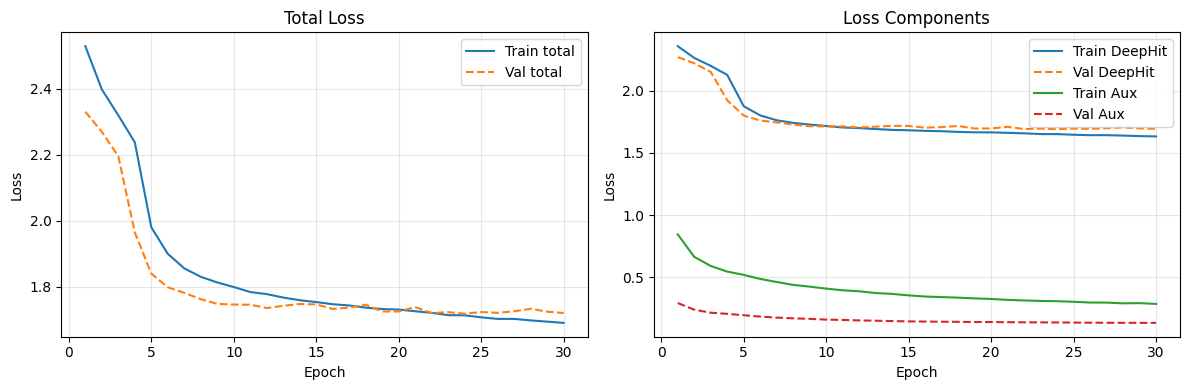

In [12]:
epochs_ran = len(train_total_losses)
x_ep = np.arange(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_ep, train_total_losses, label='Train total')
axes[0].plot(x_ep, val_total_losses, '--', label='Val total')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x_ep, train_dh_losses, label='Train DeepHit')
axes[1].plot(x_ep, val_dh_losses, '--', label='Val DeepHit')
axes[1].plot(x_ep, train_aux_losses, label='Train Aux')
axes[1].plot(x_ep, val_aux_losses, '--', label='Val Aux')
axes[1].set_title('Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Save trained model state and preprocessing artifacts
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
model_state_path = ARTIFACTS_DIR / 'dynamic_deephit_base_net_state.pt'
meta_path = ARTIFACTS_DIR / 'dynamic_deephit_meta.pt'
# Save only the base network state dict for deployment; keep transforms separately.
torch.save(base_net.state_dict(), model_state_path)
# Save label transform and normalization stats together for reproducible inference
torch.save({
    'label_transform': label_transform,
    'feat_mean': feat_mean,
    'feat_std': feat_std,
    'MAX_TIME_S': MAX_TIME_S,
    'time_grid': time_grid,
    'output_steps': output_steps,
    'EVENT_CODES': EVENT_CODES,
}, meta_path)
print('Saved base network state to:', model_state_path)
print('Saved metadata and transforms to:', meta_path)

Saved base network state to: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\artifacts\dynamic_deephit_base_net_state.pt
Saved metadata and transforms to: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\artifacts\dynamic_deephit_meta.pt


## 11. Predict CIFs on Test Set

In [13]:
base_net.eval()

cif_test = deephit_model.predict_cif(
    X_test_np.astype('float32'),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print('CIF shape (K,T,N):', cif_test.shape)
print('CIF range:', float(cif_test.min()), float(cif_test.max()))

cif_any = cif_test[0] + cif_test[1]
print('Any-fill CIF at final time, mean:', float(cif_any[-1, :].mean()))

CIF shape (K,T,N): (2, 30, 10000)
CIF range: 7.646630365343299e-06 0.9967607855796814
Any-fill CIF at final time, mean: 0.9951949119567871


## 12. Evaluate Dynamic-DeepHit

Metrics:
- Cause-specific time-dependent concordance (Antolini)
- Event-wise and macro integrated Brier score

In [14]:
print('Time-dependent Concordance Index (Antolini):')
ctd_scores = {}

for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(1 - cif_test[k, :, :], index=time_grid)
    ev = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv='km',
    )
    ctd = ev.concordance_td('antolini')
    ctd_scores[event_name] = float(ctd)
    print(f'  {event_name:<20}: {ctd:.4f}')

macro_ctd = float(np.mean(list(ctd_scores.values())))
print('Macro C-td:', round(macro_ctd, 4))

def standard_brier_score(durations, events, cif_k, event_code, t_grid):
    bs = np.zeros(len(t_grid), dtype=np.float64)
    for j, t in enumerate(t_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        bs[j] = np.mean((label - cif_k[j, :]) ** 2)
    return bs

bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(Y_test, D_test, cif_test[k], event_code, time_grid)

trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
t_min, t_max = time_grid[0], time_grid[-1]
ibs_scores = {
    name: float(trapz_fn(curve, time_grid) / (t_max - t_min))
    for name, curve in bs_curves.items()
}
macro_ibs = float(np.mean(list(ibs_scores.values())))

print('Integrated Brier Score:')
for name, ibs in ibs_scores.items():
    print(f'  {name:<20}: {ibs:.4f}')
print('Macro IBS:', round(macro_ibs, 4))

Time-dependent Concordance Index (Antolini):
  FAVORABLE_FILL      : 0.8759
  TOXIC_FILL          : 0.8846
Macro C-td: 0.8803
Integrated Brier Score:
  FAVORABLE_FILL      : 0.2228
  TOXIC_FILL          : 0.2195
Macro IBS: 0.2212


Final-time probability means:
  CIF(FAVORABLE) mean: 0.4864
  CIF(TOXIC) mean    : 0.5088
  Survival mean      : 0.0048


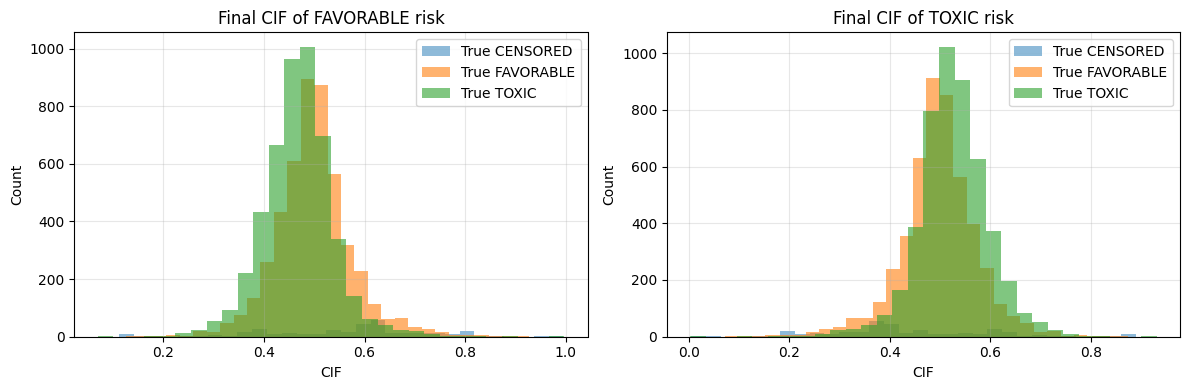

In [15]:
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

mask_cens = D_test == 0
mask_fav = D_test == 1
mask_tox = D_test == 2

print('Final-time probability means:')
print('  CIF(FAVORABLE) mean:', round(float(final_cif_fav.mean()), 4))
print('  CIF(TOXIC) mean    :', round(float(final_cif_tox.mean()), 4))
print('  Survival mean      :', round(float(final_surv.mean()), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label='True CENSORED')
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label='True FAVORABLE')
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label='True TOXIC')
axes[0].set_title('Final CIF of FAVORABLE risk')
axes[0].set_xlabel('CIF')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label='True CENSORED')
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label='True FAVORABLE')
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label='True TOXIC')
axes[1].set_title('Final CIF of TOXIC risk')
axes[1].set_xlabel('CIF')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Entry-time-only evaluation: keep only the initial prediction context at order placement.
X_test_initial = np.zeros_like(X_test_np)
for i in range(X_test_np.shape[0]):
    l = int(min(ENTRY_HISTORY_STEPS, L_test[i], X_test_np.shape[1]))
    if l > 0:
        X_test_initial[i, :l, :] = X_test_np[i, :l, :]
        X_test_initial[i, :l, -1] = 1.0

cif_test_initial = deephit_model.predict_cif(
    X_test_initial.astype('float32'),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
 )

print('Entry-time-only metrics (initial prediction at order placement):')
print('Time-dependent Concordance Index (Antolini):')
ctd_scores_initial = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(1 - cif_test_initial[k, :, :], index=time_grid)
    ev = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv='km',
    )
    ctd = ev.concordance_td('antolini')
    ctd_scores_initial[event_name] = float(ctd)
    print(f'  {event_name:<20}: {ctd:.4f}')

macro_ctd_initial = float(np.mean(list(ctd_scores_initial.values())))
print('Macro C-td:', round(macro_ctd_initial, 4))

def standard_brier_score_entry(durations, events, cif_k, event_code, t_grid):
    bs = np.zeros(len(t_grid), dtype=np.float64)
    for j, t in enumerate(t_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        bs[j] = np.mean((label - cif_k[j, :]) ** 2)
    return bs

bs_curves_initial = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves_initial[event_name] = standard_brier_score_entry(
        Y_test, D_test, cif_test_initial[k], event_code, time_grid
    )

trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
t_min, t_max = time_grid[0], time_grid[-1]
ibs_scores_initial = {
    name: float(trapz_fn(curve, time_grid) / (t_max - t_min))
    for name, curve in bs_curves_initial.items()
}
macro_ibs_initial = float(np.mean(list(ibs_scores_initial.values())))

print('Integrated Brier Score:')
for name, ibs in ibs_scores_initial.items():
    print(f'  {name:<20}: {ibs:.4f}')
print('Macro IBS:', round(macro_ibs_initial, 4))

Entry-time-only metrics (initial prediction at order placement):
Time-dependent Concordance Index (Antolini):
  FAVORABLE_FILL      : 0.5987
  TOXIC_FILL          : 0.6046
Macro C-td: 0.6016
Integrated Brier Score:
  FAVORABLE_FILL      : 0.2405
  TOXIC_FILL          : 0.2470
Macro IBS: 0.2437


In [17]:
# Leakage diagnostics for high full-sequence C-td
print('=== Leakage Diagnostics ===')

# 1) Chronological split integrity check
train_max_ts = int(T_all[train_mask].max())
val_min_ts = int(T_all[val_mask].min())
val_max_ts = int(T_all[val_mask].max())
test_min_ts = int(T_all[test_mask].min())
is_chrono_clean = (train_max_ts < val_min_ts) and (val_max_ts < test_min_ts)
print('Chronological split clean:', is_chrono_clean)
print('  train_max_ts < val_min_ts :', train_max_ts < val_min_ts)
print('  val_max_ts < test_min_ts  :', val_max_ts < test_min_ts)

# 2) Coupling between sequence length and remaining-time target
elapsed_test_s = np.maximum(L_test - ENTRY_HISTORY_STEPS, 0) * STEP_SECONDS
corr_len_vs_remaining = float(np.corrcoef(L_test.astype(float), Y_test.astype(float))[0, 1])
corr_elapsed_vs_remaining = float(np.corrcoef(elapsed_test_s.astype(float), Y_test.astype(float))[0, 1])
print('Correlation(length, remaining_time):', round(corr_len_vs_remaining, 4))
print('Correlation(elapsed_from_length, remaining_time):', round(corr_elapsed_vs_remaining, 4))

# 3) Length-only baseline (no market features)
score_len = np.maximum(L_test - ENTRY_HISTORY_STEPS, 0).astype(np.float64)
z = (score_len - score_len.mean()) / (score_len.std() + 1e-8)
lambda_i = np.exp(0.35 * z)
time_scale = max(float(np.median(Y_test)), 1e-6)
surv_len_only = np.exp(-np.outer((time_grid / time_scale).astype(np.float64), lambda_i))
cif_len_only = 1.0 - surv_len_only

ctd_len = {}
ibs_len = {}
for event_code, event_name in zip(EVENT_CODES, EVENT_NAMES):
    one_minus_cif_df = pd.DataFrame(surv_len_only, index=time_grid)
    ev_len = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv='km',
    )
    ctd_len[event_name] = float(ev_len.concordance_td('antolini'))

    bs_curve = np.zeros(len(time_grid), dtype=np.float64)
    for j, t in enumerate(time_grid):
        label = ((Y_test <= t) & (D_test == event_code)).astype(float)
        bs_curve[j] = np.mean((label - cif_len_only[j, :]) ** 2)
    ibs_len[event_name] = float(trapz_fn(bs_curve, time_grid) / (time_grid[-1] - time_grid[0]))

macro_ctd_len = float(np.mean(list(ctd_len.values())))
macro_ibs_len = float(np.mean(list(ibs_len.values())))

print('\nLength-only baseline metrics:')
for name in EVENT_NAMES:
    print(f'  {name:<20}: C-td={ctd_len[name]:.4f}, IBS={ibs_len[name]:.4f}')
print('  Macro C-td:', round(macro_ctd_len, 4))
print('  Macro IBS :', round(macro_ibs_len, 4))

# 4) Permutation sanity check (break sample-to-label alignment)
rng_diag = np.random.default_rng(SEED + 123)
perm_idx = rng_diag.permutation(X_test_np.shape[0])
X_test_perm = X_test_np[perm_idx]
cif_perm = deephit_model.predict_cif(
    X_test_perm.astype('float32'),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
 )

ctd_perm = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(1 - cif_perm[k, :, :], index=time_grid)
    ev_perm = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv='km',
    )
    ctd_perm[event_name] = float(ev_perm.concordance_td('antolini'))

macro_ctd_perm = float(np.mean(list(ctd_perm.values())))
print('\nPermutation sanity-check C-td:')
for name in EVENT_NAMES:
    print(f'  {name:<20}: {ctd_perm[name]:.4f}')
print('  Macro C-td:', round(macro_ctd_perm, 4))

print('\nReference from current notebook:')
print('  Full dynamic Macro C-td        :', round(float(macro_ctd), 4))
print('  Entry-time-only Macro C-td     :', round(float(macro_ctd_initial), 4))
print('  Length-only baseline Macro C-td:', round(float(macro_ctd_len), 4))
print('  Permuted-input Macro C-td      :', round(float(macro_ctd_perm), 4))

=== Leakage Diagnostics ===
Chronological split clean: True
  train_max_ts < val_min_ts : True
  val_max_ts < test_min_ts  : True
Correlation(length, remaining_time): 0.5393
Correlation(elapsed_from_length, remaining_time): 0.5393

Length-only baseline metrics:
  FAVORABLE_FILL      : C-td=0.1281, IBS=0.5644
  TOXIC_FILL          : C-td=0.1120, IBS=0.5427
  Macro C-td: 0.12
  Macro IBS : 0.5535

Permutation sanity-check C-td:
  FAVORABLE_FILL      : 0.5063
  TOXIC_FILL          : 0.5022
  Macro C-td: 0.5042

Reference from current notebook:
  Full dynamic Macro C-td        : 0.8803
  Entry-time-only Macro C-td     : 0.6016
  Length-only baseline Macro C-td: 0.12
  Permuted-input Macro C-td      : 0.5042


In [18]:
# Quick robustness check: length-only baseline with both risk directions
score_len = np.maximum(L_test - ENTRY_HISTORY_STEPS, 0).astype(np.float64)
z = (score_len - score_len.mean()) / (score_len.std() + 1e-8)
time_scale = max(float(np.median(Y_test)), 1e-6)

def macro_ctd_from_z(z_dir):
    lam = np.exp(0.35 * z_dir)
    surv = np.exp(-np.outer((time_grid / time_scale).astype(np.float64), lam))
    vals = []
    for event_code in EVENT_CODES:
        one_minus_cif_df = pd.DataFrame(surv, index=time_grid)
        ev_tmp = EvalSurv(
            one_minus_cif_df,
            Y_test,
            (D_test == event_code).astype(int),
            censor_surv='km',
        )
        vals.append(float(ev_tmp.concordance_td('antolini')))
    return float(np.mean(vals))

macro_ctd_dir_plus = macro_ctd_from_z(+z)
macro_ctd_dir_minus = macro_ctd_from_z(-z)
print('Length-only Macro C-td (z):', round(macro_ctd_dir_plus, 4))
print('Length-only Macro C-td (-z):', round(macro_ctd_dir_minus, 4))

Length-only Macro C-td (z): 0.12
Length-only Macro C-td (-z): 0.8141


In [21]:
# Fair comparison table: dynamic usefulness beyond elapsed-time information.

def compute_metrics_from_cif(cif_tensor, durations, events, t_grid, event_codes, event_names):
    ctd_scores_local = {}
    ibs_scores_local = {}

    for k, (event_code, event_name) in enumerate(zip(event_codes, event_names)):
        one_minus_cif_df = pd.DataFrame(1.0 - cif_tensor[k, :, :], index=t_grid)
        ev = EvalSurv(
            one_minus_cif_df,
            durations,
            (events == event_code).astype(int),
            censor_surv='km',
        )
        ctd_scores_local[event_name] = float(ev.concordance_td('antolini'))

        bs_curve = np.zeros(len(t_grid), dtype=np.float64)
        for j, t in enumerate(t_grid):
            label = ((durations <= t) & (events == event_code)).astype(float)
            bs_curve[j] = np.mean((label - cif_tensor[k, j, :]) ** 2)
        ibs_scores_local[event_name] = float(
            trapz_fn(bs_curve, t_grid) / (t_grid[-1] - t_grid[0])
        )

    return (
        float(np.mean(list(ctd_scores_local.values()))),
        float(np.mean(list(ibs_scores_local.values()))),
        ctd_scores_local,
        ibs_scores_local,
    )

def compute_metrics_from_survival(surv_mat, durations, events, t_grid, event_codes, event_names):
    ctd_scores_local = {}
    ibs_scores_local = {}
    cif_proxy = 1.0 - surv_mat

    for event_code, event_name in zip(event_codes, event_names):
        one_minus_cif_df = pd.DataFrame(surv_mat, index=t_grid)
        ev = EvalSurv(
            one_minus_cif_df,
            durations,
            (events == event_code).astype(int),
            censor_surv='km',
        )
        ctd_scores_local[event_name] = float(ev.concordance_td('antolini'))

        bs_curve = np.zeros(len(t_grid), dtype=np.float64)
        for j, t in enumerate(t_grid):
            label = ((durations <= t) & (events == event_code)).astype(float)
            bs_curve[j] = np.mean((label - cif_proxy[j, :]) ** 2)
        ibs_scores_local[event_name] = float(
            trapz_fn(bs_curve, t_grid) / (t_grid[-1] - t_grid[0])
        )

    return (
        float(np.mean(list(ctd_scores_local.values()))),
        float(np.mean(list(ibs_scores_local.values()))),
        ctd_scores_local,
        ibs_scores_local,
    )

# 1) Full dynamic model metrics
full_macro_ctd, full_macro_ibs, _, _ = compute_metrics_from_cif(
    cif_test, Y_test, D_test, time_grid, EVENT_CODES, EVENT_NAMES
)

# 2) Entry-time-only (proxy for static information set)
entry_macro_ctd, entry_macro_ibs, _, _ = compute_metrics_from_cif(
    cif_test_initial, Y_test, D_test, time_grid, EVENT_CODES, EVENT_NAMES
)

# 3) Elapsed-time (length-only) baseline; evaluate both directions and keep better C-td
score_len = np.maximum(L_test - ENTRY_HISTORY_STEPS, 0).astype(np.float64)
z = (score_len - score_len.mean()) / (score_len.std() + 1e-8)
time_scale = max(float(np.median(Y_test)), 1e-6)

def survival_from_z(z_dir):
    lam = np.exp(0.35 * z_dir)
    return np.exp(-np.outer((time_grid / time_scale).astype(np.float64), lam))

surv_plus = survival_from_z(+z)
surv_minus = survival_from_z(-z)
plus_ctd, plus_ibs, _, _ = compute_metrics_from_survival(
    surv_plus, Y_test, D_test, time_grid, EVENT_CODES, EVENT_NAMES
)
minus_ctd, minus_ibs, _, _ = compute_metrics_from_survival(
    surv_minus, Y_test, D_test, time_grid, EVENT_CODES, EVENT_NAMES
)

if minus_ctd >= plus_ctd:
    base_macro_ctd = minus_ctd
    base_macro_ibs = minus_ibs
    base_name = 'Elapsed-Time Baseline (best-dir: -z)'
else:
    base_macro_ctd = plus_ctd
    base_macro_ibs = plus_ibs
    base_name = 'Elapsed-Time Baseline (best-dir: +z)'

# 4) Permuted-input sanity model
rng_cmp = np.random.default_rng(SEED + 2026)
perm_idx_cmp = rng_cmp.permutation(X_test_np.shape[0])
cif_perm_cmp = deephit_model.predict_cif(
    X_test_np[perm_idx_cmp].astype('float32'),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
 )
perm_macro_ctd, perm_macro_ibs, _, _ = compute_metrics_from_cif(
    cif_perm_cmp, Y_test, D_test, time_grid, EVENT_CODES, EVENT_NAMES
)

rows = [
    {'Model': 'Full Dynamic', 'Macro C-td': full_macro_ctd, 'Macro IBS': full_macro_ibs},
    {'Model': 'Entry-Time Only (proxy static)', 'Macro C-td': entry_macro_ctd, 'Macro IBS': entry_macro_ibs},
    {'Model': base_name, 'Macro C-td': base_macro_ctd, 'Macro IBS': base_macro_ibs},
    {'Model': 'Permuted Input (sanity)', 'Macro C-td': perm_macro_ctd, 'Macro IBS': perm_macro_ibs},
]

for r in rows:
    r['Delta C-td vs elapsed baseline'] = r['Macro C-td'] - base_macro_ctd
    r['Delta IBS vs elapsed baseline'] = base_macro_ibs - r['Macro IBS']

df_compare = pd.DataFrame(rows)
df_compare = df_compare.sort_values('Macro C-td', ascending=False).reset_index(drop=True)

print('=== Static vs Dynamic Fair Comparison (Uplift over elapsed-time baseline) ===')
display(
    df_compare.style.format({
        'Macro C-td': '{:.4f}',
        'Macro IBS': '{:.4f}',
        'Delta C-td vs elapsed baseline': '{:+.4f}',
        'Delta IBS vs elapsed baseline': '{:+.4f}',
    })
)

=== Static vs Dynamic Fair Comparison (Uplift over elapsed-time baseline) ===


,Model,Macro C-td,Macro IBS,Delta C-td vs elapsed baseline,Delta IBS vs elapsed baseline
0,Full Dynamic,0.8803,0.2212,+0.0661,+0.3212
1,Elapsed-Time Baseline (best-dir: -z),0.8141,0.5423,+0.0000,+0.0000
2,Entry-Time Only (proxy static),0.6016,0.2437,-0.2125,+0.2986
3,Permuted Input (sanity),0.5043,0.2578,-0.3098,+0.2845
